# Customer Segmentation & Behavior Analysis

**Overview**: This notebook focuses on data preparation, feature engineering, and exploratory data analysis (EDA). The primary objective is to segment customers based on their purchasing behavior, lifetime value, and engagement metrics to drive targeted marketing strategies

## 1. Setup & Data Loading
In this section, we initialize our analytical environment, import required libraries, and ingest the pre-cleaned datasets for downstream processing.

### 1.1. Import Libraries & Environment Setup

In [5258]:
# Import core analytical and visualization libraries
import pandas as pd
import numpy as np
import os
import calendar
import warnings

# Data visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter


# Ignore warning messages for cleaner notebook output
warnings.filterwarnings('ignore')

# Set plotting style and default figure size for consistency
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1.2. Load Datasets
Loading the cleaned `.parquet` files from the processed dataset directory.

In [5259]:
DATA_PATH = '../dataset/02_after_clean/'
print("Loading data...")

df_customers = pd.read_parquet(DATA_PATH + 'customers.parquet')
df_promotions = pd.read_parquet(DATA_PATH + 'promotions.parquet')
df_geography = pd.read_parquet(DATA_PATH + 'geography.parquet')

df_orders = pd.read_parquet(DATA_PATH + 'orders.parquet')
df_returns = pd.read_parquet(DATA_PATH + 'returns.parquet')
df_reviews = pd.read_parquet(DATA_PATH + 'reviews.parquet')

print("Load data successfully")

Loading data...
Load data successfully


## 2. Data Preprocessing & Feature Engineering
To accurately segment our customers, we need to extract meaningful features from raw transaction logs.

### 2.1. Time-Based Features Generation
Calculating temporal metrics such as the average days between purchases (interval), customer tenure, and recency to understand engagement frequency.

In [5260]:
# Sort orders chronologically per customer
df_orders = df_orders.sort_values(by=['customer_id', 'order_date'])

# Calculate the interval (in days) between consecutive orders for each customer
df_orders['interval_prev_order'] = (
    df_orders.groupby('customer_id')['order_date']
    .diff()
    .dt.days
)

# Calculate the average interval between orders for each customer
inter_order_gap = (
    df_orders.groupby('customer_id')['interval_prev_order']
    .apply(lambda x: x.iloc[1:].mean())
)
df_customers['avg_interval'] = df_customers['customer_id'].map(inter_order_gap).fillna(0.0)

# Determine the first and last order dates
first_order = df_orders.groupby('customer_id')['order_date'].first()
last_order = df_orders.groupby('customer_id')['order_date'].last()

# Map dates to customers (fallback to signup_date if no orders)
df_customers['first_order_date'] = df_customers['customer_id'].map(first_order).fillna(df_customers['signup_date'])
df_customers['last_order_date'] = df_customers['customer_id'].map(last_order).fillna(df_customers['signup_date'])

# Calculate Recency and Tenure (Reference date: Dec 31, 2022)
current_date = pd.to_datetime('2022-12-31', dayfirst=True)
df_customers['recency_days'] = (current_date - df_customers['last_order_date']).dt.days
df_customers['tenure_days'] = (current_date - df_customers['first_order_date']).dt.days

display(df_customers.sample(3))

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel,avg_interval,first_order_date,last_order_date,recency_days,tenure_days
24081,31053,48618,Cam Pha,2017-05-20,Female,35-44,social_media,967.0,2012-08-24,2020-08-03,880,3781
115229,148877,98132,Can Tho,2018-06-28,Male,18-24,email_campaign,0.0,2022-05-01,2022-05-01,244,244
111792,144440,85934,Da Lat,2020-10-31,Female,35-44,organic_search,0.0,2020-10-31,2020-10-31,791,791


### 2.2. Order & Payment Features Aggregation
Extracting order-level financial metrics and aggregating them at the customer level to determine total lifetime orders, actual revenue, and refund/cancellation rates.

#### Order-level feature preparation

In [5261]:
# Calculate total refund amount per order
total_refund_per_order = df_returns.groupby('order_id')['refund_amount'].sum()
df_orders['refund_amount'] = df_orders['order_id'].map(total_refund_per_order).fillna(0.0)

# Identify monetary values of cancelled and returned orders
df_orders['cancel_refund'] = (df_orders[df_orders['order_status'] == 'cancelled']['payment_value'])
df_orders['cancel_refund'] = df_orders['cancel_refund'].fillna(0.0)
df_orders['total_refund'] = df_orders['cancel_refund'] + df_orders['refund_amount']

# Calculate actual payment and boolean flag for successful orders
df_orders['actual_payment'] = df_orders['payment_value'] - df_orders['total_refund']
df_orders['is_actual_order'] = (df_orders['order_status'] != 'cancelled') & (df_orders['order_status'] != 'returned')

display(df_orders.sample(3))


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,payment_value,installments,interval_prev_order,refund_amount,cancel_refund,total_refund,actual_payment,is_actual_order
167950,216723,2014-08-29,151414,89503,returned,credit_card,desktop,organic_search,8242.92,6 periods,269.0,4613.48,0.0,4613.48,3629.44,False
418241,539284,2017-10-11,64153,20602,delivered,paypal,mobile,social_media,11324.91,1 period,132.0,0.00,0.0,0.00,11324.91,True
81649,105364,2013-08-03,58931,1527,delivered,credit_card,mobile,organic_search,43392.96,12 periods,133.0,0.00,0.0,0.00,43392.96,True


#### Customer-level aggregation

In [5262]:
# Count orders by status
total_order_per_cus = df_orders.groupby('customer_id')['order_id'].count()
total_return_order_per_cus = df_orders[df_orders['order_status'] == 'returned'].groupby('customer_id')['order_id'].count()
total_cancelled_order_per_cus = df_orders[df_orders['order_status'] == 'cancelled'].groupby('customer_id')['order_id'].count()

# Sum payments by status
total_paid_per_cus = df_orders.groupby('customer_id')['payment_value'].sum()
total_refund_per_cus = df_orders.groupby('customer_id')['refund_amount'].sum()
total_refund_cancelled_per_cus = df_orders.groupby('customer_id')['cancel_refund'].sum()
actual_paid_per_cus = df_orders.groupby('customer_id')['actual_payment'].sum()

# Map aggregated data to the customers dataframe
df_customers['total_order'] = df_customers['customer_id'].map(total_order_per_cus).fillna(0)
df_customers['return_order'] = df_customers['customer_id'].map(total_return_order_per_cus).fillna(0)
df_customers['cancel_order'] = df_customers['customer_id'].map(total_cancelled_order_per_cus).fillna(0)
df_customers['actual_order'] = df_customers['total_order'] - df_customers['return_order'] - df_customers['cancel_order']

df_customers['total_paid'] = df_customers['customer_id'].map(total_paid_per_cus).fillna(0)
df_customers['total_refund'] = df_customers['customer_id'].map(total_refund_per_cus).fillna(0)
df_customers['total_refund_cancel'] = df_customers['customer_id'].map(total_refund_cancelled_per_cus).fillna(0)
df_customers['actual_paid'] = df_customers['customer_id'].map(actual_paid_per_cus).fillna(0)

# Calculate Return/Cancellation Rate
df_customers['return_cancel_rate'] = ((df_customers['return_order'] + df_customers['cancel_order']) / df_customers['total_order']).fillna(-1.0)

display(df_customers.sample(3))

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel,avg_interval,first_order_date,last_order_date,...,tenure_days,total_order,return_order,cancel_order,actual_order,total_paid,total_refund,total_refund_cancel,actual_paid,return_cancel_rate
97623,126141,76827,Hoi An,2018-02-16,Male,18-24,referral,2.000000,2019-08-29,2019-08-31,...,1220,2.0,0.0,0.0,2.0,16036.12,0.0,0.00,16036.12,0.0
8982,11534,11374,Son Tay,2020-08-29,Female,45-54,organic_search,338.111111,2014-08-29,2022-12-28,...,3046,10.0,1.0,1.0,8.0,199078.31,10596.9,29897.44,158583.97,0.2
36184,46633,40222,Thai Nguyen,2018-08-04,Male,35-44,organic_search,403.800000,2012-11-21,2018-06-02,...,3692,6.0,0.0,0.0,6.0,81685.82,0.0,0.00,81685.82,0.0


### 2.3. Rule-Based Customer Segmentation
Categorizing customers into 7 distinct, mutually exclusive segments (including the default 'loyal' segment) based on their historical purchasing behavior, recency, and lifetime value.

In [5263]:
# Define thresholds for segmentation
six_months_ago = pd.to_datetime('2022-05-31', dayfirst=True)
three_years_ago = pd.to_datetime('2019-12-31', dayfirst=True)

# Use quantiles for dynamic thresholds
high_inter_threshold = df_customers['avg_interval'].quantile(0.25)
high_paid_threshold = df_customers['actual_paid'].quantile(0.75)

# Define segmentation conditions
conditions = [
    # Non buyer
    df_customers['total_order'] == 0,
    # New customer
    ((df_customers['signup_date'] >= six_months_ago) |
     (df_customers['first_order_date'] >= six_months_ago)) & 
    (df_customers['total_order'] <= 2),
    # Low quality customer
    (df_customers['return_cancel_rate'] >= 0.75) | 
    (df_customers['actual_paid'] < df_customers['total_paid'] * 0.5),
    # Old customer
    (df_customers['last_order_date'] < three_years_ago),
    # High-value loyal
    (df_customers['actual_order'] > 1) & 
    (df_customers['return_cancel_rate'] < 0.3) & 
    (df_customers['actual_paid'] >= high_paid_threshold) &
    (df_customers['recency_days'] <= df_customers['avg_interval']),
    # At-risk
    #(df_customers['actual_order'] == 1) |
    (df_customers['return_cancel_rate'] >= 0.5) | 
    (df_customers['recency_days'] > df_customers['avg_interval'] * 1.5),
]

# Map conditions to segment labels
choices = [
    'non_buyer',
    'new_customer',
    'low_quality',
    'old_customer',
    'high_value_loyal',
    'at_risk'
]

# Apply segmentation, default to 'loyal' if no conditions are met
df_customers['customer_segment'] = np.select(conditions, choices, default='loyal')
df_customers['customer_segment'] = df_customers['customer_segment'].astype('category')

In [5264]:
# Define segmentation conditions
# conditions = [
#     # Non buyer
#     df_customers['total_order'] == 0,
#     # New customer
#     (((df_customers['signup_date'] >= six_months_ago) |
#      (df_customers['first_order_date'] >= six_months_ago)) & 
#     (df_customers['total_order'] <= 2)) | 
#     # Low quality customer
#     ((df_customers['return_cancel_rate'] >= 0.75) | 
#     (df_customers['actual_paid'] < df_customers['total_paid'] * 0.5)),
# ]

# # Map conditions to segment labels
# choices = [
#     'non_buyer',
#     'little_order'
# ]

# # Apply segmentation, default to 'loyal' if no conditions are met
# df_customers['customer_segment'] = np.select(conditions, choices, default='many_order')
# df_customers['customer_segment'] = df_customers['customer_segment'].astype('category')

In [5265]:
print(df_customers['customer_segment'].value_counts())

customer_segment
old_customer        35816
non_buyer           31684
loyal               16790
at_risk             15588
high_value_loyal    11660
low_quality          6176
new_customer         4216
Name: count, dtype: int64


### 2.4. Data Merging & Formatting
Merging geographical data and segment tags back to operational tables (returns, orders) for deeper cohort analysis and tracking daily aggregated metrics.

In [5266]:
# Prepare Return Data by attaching Customer Segment
df_returns = df_returns.merge(df_orders[['order_id', 'customer_id']], on='order_id', how='left')
df_returns = df_returns.merge(df_customers[['customer_id', 'customer_segment']], on='customer_id', how='left')

# Prepare Review Data by attaching Customer Segment
df_reviews = df_reviews.merge(df_customers[['customer_id', 'customer_segment']], on='customer_id', how='left')

# Add Geography to Customers
df_customers = df_customers.merge(df_geography[['zip', 'region']], on='zip', how='left')

# Prepare Time-Series Order & Payment Data grouped by Segment
df_orders = df_orders.merge(df_customers[['customer_id', 'customer_segment']], on='customer_id', how='left')

daily_segment_df = df_orders.groupby(['order_date', 'customer_segment'], observed=True).agg(
    total_order=('order_id', 'count'),
    actual_order=('is_actual_order', 'sum'),
    return_cancel_order=('is_actual_order', lambda x: (x == 0).sum()),
    total_paid=('payment_value', 'sum'), 
    actual_paid=('actual_payment', 'sum'),
    total_refund=('total_refund', 'sum')
).reset_index()

display(daily_segment_df.sample(3))


,order_date,customer_segment,total_order,actual_order,return_cancel_order,total_paid,actual_paid,total_refund
4407,2014-08-16,at_risk,49,41,8,1329064.25,1222538.39,106525.86
17403,2021-03-31,at_risk,145,128,17,3481382.00,3168712.02,312669.98
3049,2013-12-25,high_value_loyal,64,54,10,685664.21,613038.54,72625.67


### 2.5. Promotional Data Preparation
Formatting datetime features and extracting seasonal indicators to analyze the life cycle and distribution of promotional campaigns.

In [5267]:
# Convert date columns to datetime objects and calculate promotion duration
df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])
df_promotions['duration_days'] = (df_promotions['end_date'] - df_promotions['start_date']).dt.days

# Verify the timeline boundaries of the promotions dataset
newest_end_promo = df_promotions[df_promotions['end_date'] == df_promotions['end_date'].max()]
print(f"Latest promotion end date: {newest_end_promo['end_date'].iloc[0]}")

oldest_start_promo = df_promotions[df_promotions['start_date'] == df_promotions['start_date'].min()]
print(f"\nEarliest promotion start date: {oldest_start_promo['start_date'].iloc[0]}")

# Extract time components for seasonality analysis
df_promotions['month'] = df_promotions['start_date'].dt.month
df_promotions['year'] = df_promotions['start_date'].dt.year

# Create Day-Month strings to identify recurring annual events
df_promotions['start_day_month'] = df_promotions['start_date'].dt.strftime('%d-%m')
df_promotions['end_day_month'] = df_promotions['end_date'].dt.strftime('%d-%m')

# Sort promotions chronologically by their annual start day
df_promotions = df_promotions.sort_values(by=['start_day_month', 'start_date'])

Latest promotion end date: 2022-12-31 00:00:00

Earliest promotion start date: 2013-01-31 00:00:00


### 2.6. Feature Selection & Data Export
Dropping irrelevant columns to optimize memory usage, reviewing the final structure of our dataset and exporting the prepared data for the EDA phase.

In [5268]:
EXPORT_PATH = '../dataset/03_after_eda/'
os.makedirs(EXPORT_PATH, exist_ok=True)

# Drop operational columns that are no longer needed for high-level segment analysis
df_returns = df_returns.drop(columns=['order_id', 'product_id', 'return_date', 'return_quantity'])
df_reviews = df_reviews.drop(columns=['order_id', 'product_id', 'review_date', 'review_title'])
df_customers = df_customers.drop(columns=['zip', 'city', 'gender', 'age_group', 'acquisition_channel'])

# Review dataset schemas and non-null counts
df_orders.info()
df_returns.info()
df_reviews.info()
df_customers.info()
daily_segment_df.info()
df_promotions.info()

# Export the processed dataframes
df_customers.to_parquet(EXPORT_PATH + 'customers_segment.parquet', index=False)
df_promotions.to_parquet(EXPORT_PATH + 'promotions.parquet', index=False)
daily_segment_df.to_parquet(EXPORT_PATH + 'daily_segment.parquet', index=False)

print("Data preparation complete.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             646945 non-null  string        
 1   order_date           646945 non-null  datetime64[ns]
 2   customer_id          646945 non-null  string        
 3   zip                  646945 non-null  string        
 4   order_status         646945 non-null  category      
 5   payment_method       646945 non-null  category      
 6   device_type          646945 non-null  category      
 7   order_source         646945 non-null  category      
 8   payment_value        646945 non-null  float64       
 9   installments         646945 non-null  category      
 10  interval_prev_order  556699 non-null  float64       
 11  refund_amount        646945 non-null  float64       
 12  cancel_refund        646945 non-null  float64       
 13  total_refund  

## 3. Exploratory Data Analysis (EDA)
This section visually explores the distinct behavioral patterns, financial contributions, and temporal trends of our defined customer segments to derive actionable marketing insights.


### 3.1. Defining Color Palette for Segments
Maintaining consistent colors for segments across all plots helps the audience easily identify trends.

In [5269]:
def lighten_color(color, amount=0.5):
    """
    amount: Mức độ pha trắng (từ 0 đến 1). 
    Ví dụ: 0.5 là pha 50% trắng. Số càng lớn màu càng nhạt.
    """
    # Công thức: Màu mới = Màu gốc * (1 - amount) + Màu trắng (1.0) * amount
    return tuple(c * (1 - amount) + 1.0 * amount for c in color[:3])

segment_names = [
    'at_risk', 'loyal', 'old_customer',
    'high_value_loyal', 'non_buyer', 'low_quality', 'new_customer'
]

base_colors = sns.color_palette("tab10", len(segment_names))
light_tab10 = [lighten_color(c, amount=0.5) for c in base_colors]
segment_palette = dict(zip(segment_names, light_tab10))

# Set mặc định luôn cho toàn bộ file Notebook nếu muốn
# sns.set_palette(light_tab10)

### 3.2. Customer Segmentation Overview Dashboard
A comprehensive 3x2 visualization grid comparing key behavioral metrics, revenue contributions, and signup trends across the newly created customer segments.

In [5270]:
def add_percentage_labels(ax):
    """Hàm này sẽ chạy qua các cột chồng và điền Text % vào giữa"""
    for c in ax.containers:
        # Lọc: Chỉ in số % nếu tỷ lệ đó lớn hơn 5% (0.05) để tránh chữ bị đè lên nhau ở các phần quá nhỏ
        labels = [f'{w*100:.1f}%' if (w := v.get_height()) > 0.05 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', color='white', fontsize=10, fontweight='bold')
    
    # Định dạng lại trục Y hiển thị từ 0% đến 100%
    ax.set_yticklabels([f'{int(y*100)}%' for y in ax.get_yticks()])
    ax.set_ylabel('Percentage (%)', fontsize=13)


def currency_formatter(x, pos):
    if x >= 1e9: return f'{x / 1e9:.1f} Tỷ'
    elif x >= 1e3: return f'{x / 1e6:.1f} Tr'
    return str(x)

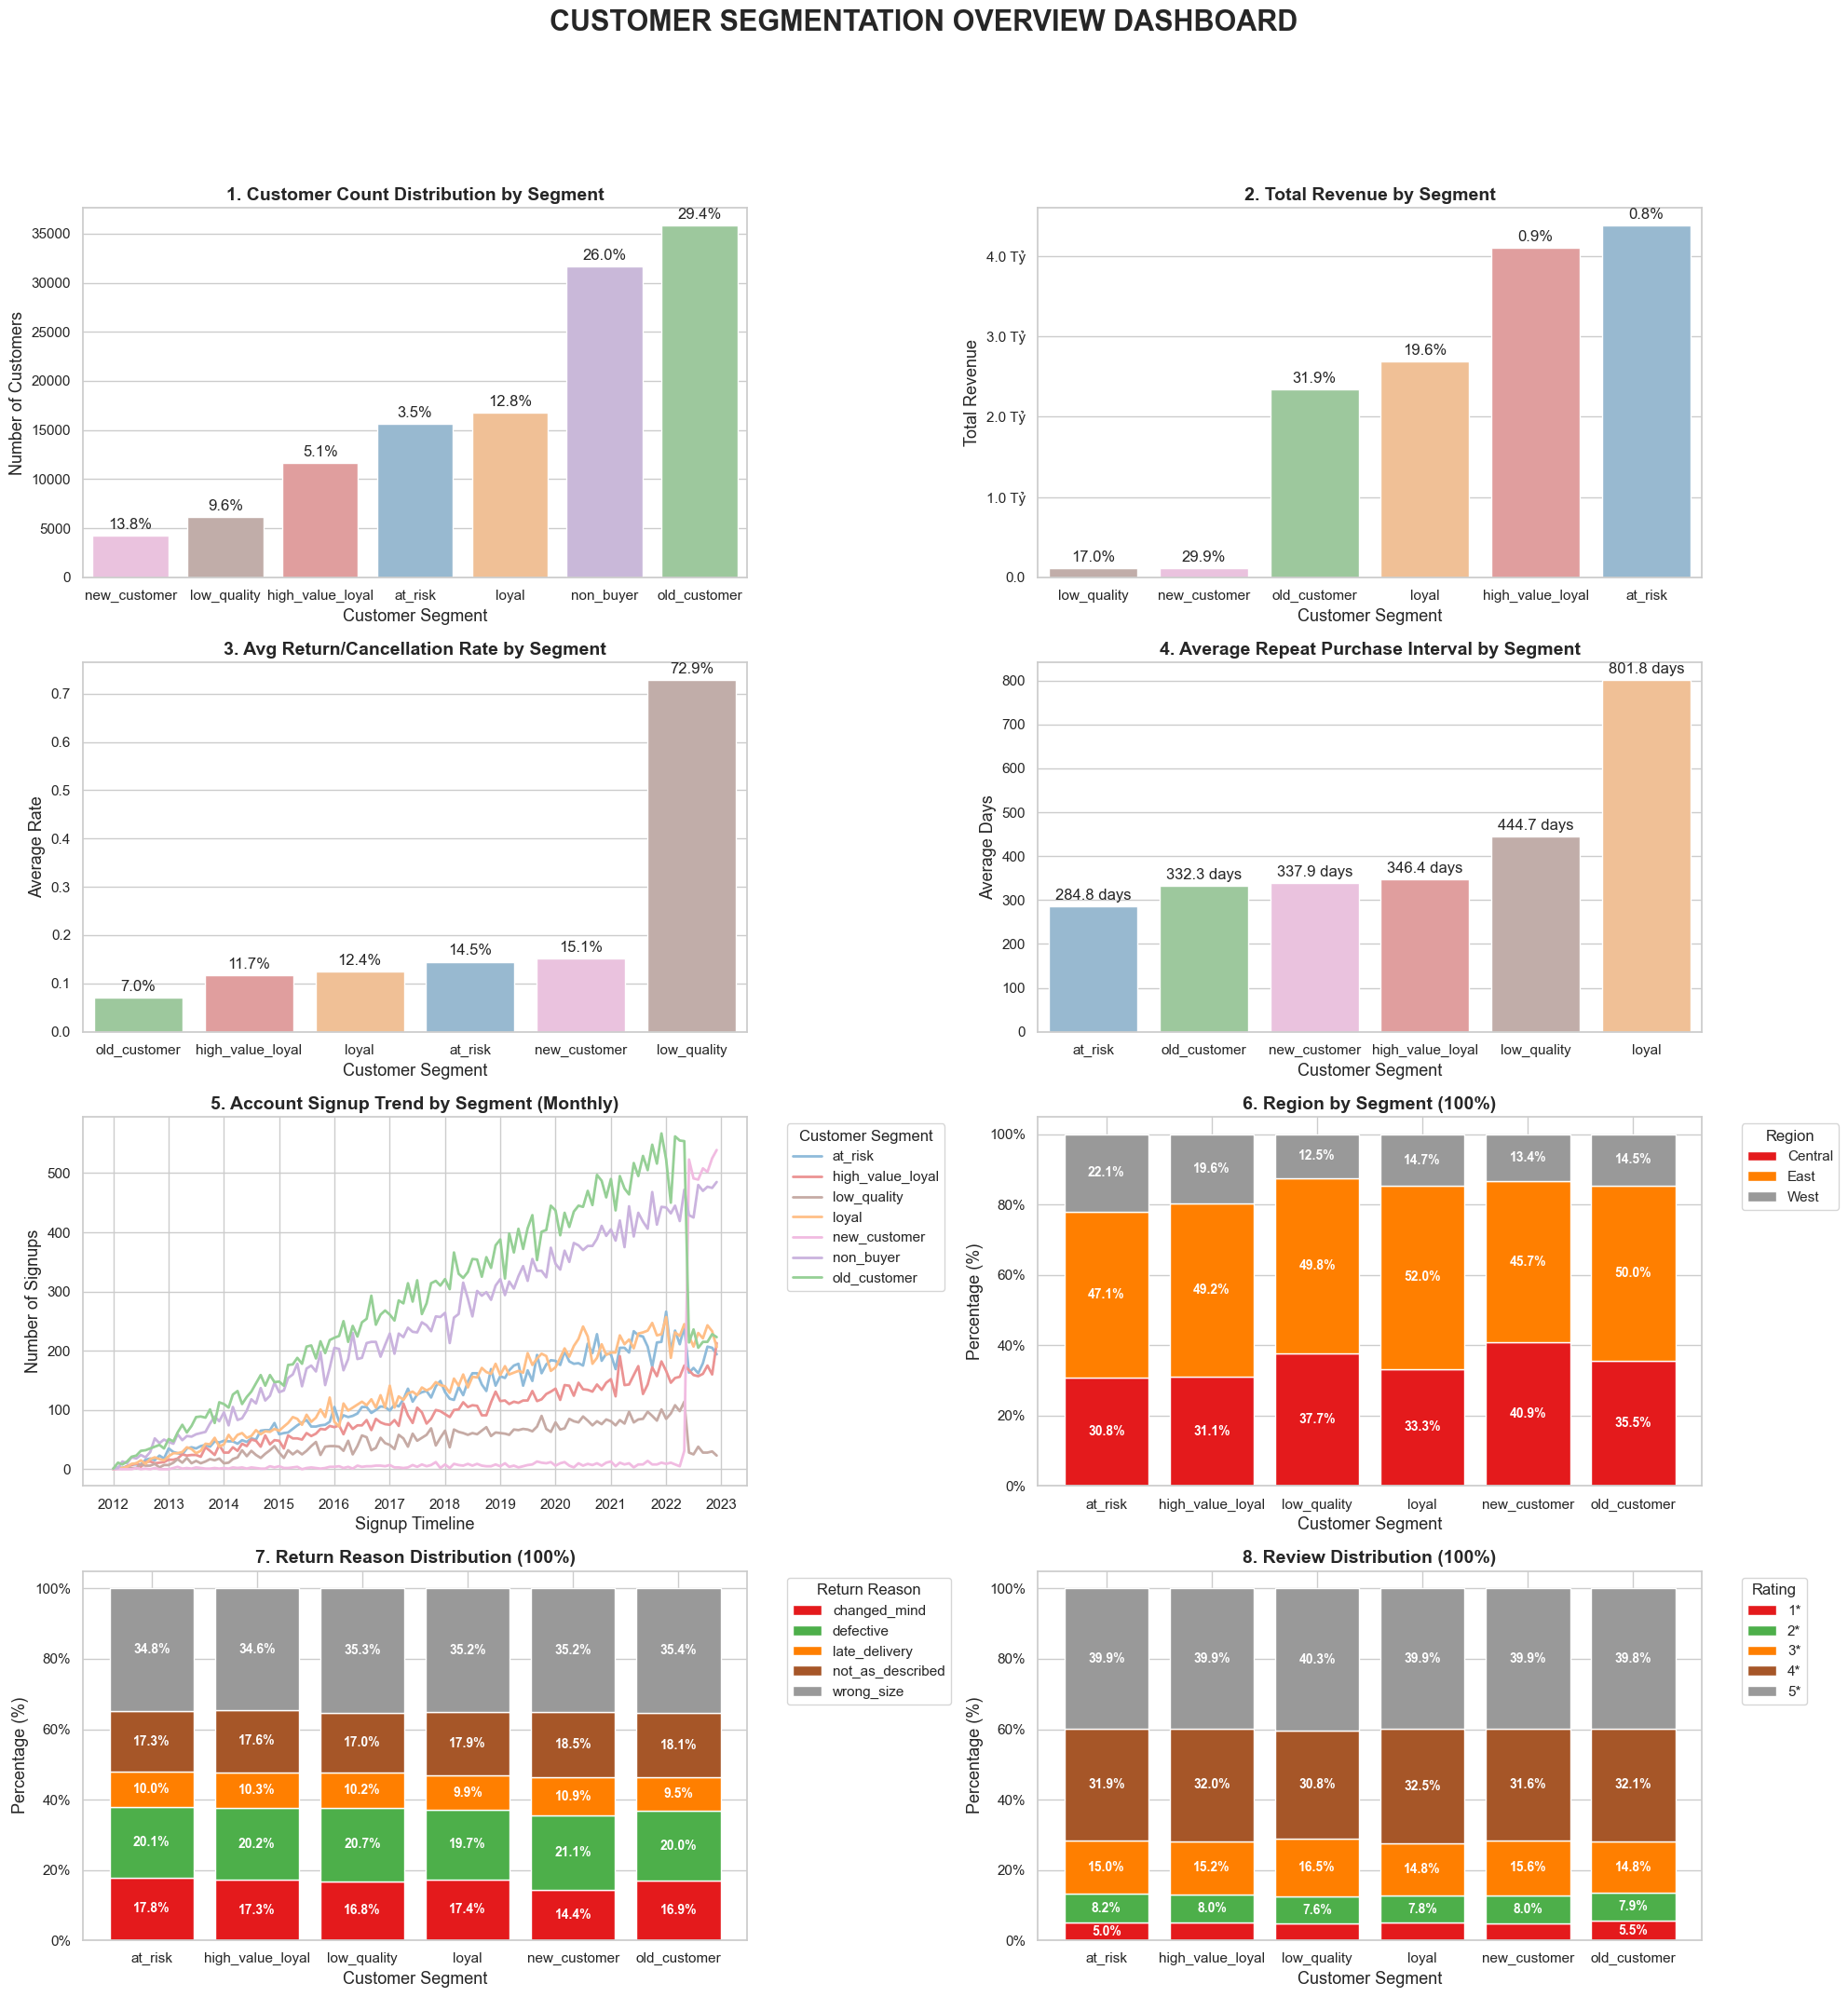

In [5271]:
# Exclude 'non_buyer' for specific behavioral analyses
df_buyers = df_customers[df_customers['customer_segment'] != 'non_buyer'].copy()
df_buyers['customer_segment'] = df_buyers['customer_segment'].cat.remove_unused_categories()


# Initialize a 3x2 subplot grid
fig, axes = plt.subplots(4, 2, figsize=(20, 21))
fig.suptitle('CUSTOMER SEGMENTATION OVERVIEW DASHBOARD', fontsize=22, fontweight='bold', y=1.02)


# ==========================================
# Plot 1: Customer Count Distribution [0, 0]
# ==========================================
counts = df_customers['customer_segment'].value_counts().reset_index()
counts.columns = ['customer_segment', 'count']
total_customers = counts['count'].sum()
counts['percentage'] = (counts['count'] / total_customers) * 100
counts = counts.sort_values(by='count', ascending=True).reset_index(drop=True)

sns.barplot(
    data=counts, 
    x='customer_segment', 
    y='count',
    hue='customer_segment', 
    palette=segment_palette,
    order=counts['customer_segment'], 
    dodge=False, legend=False,
    ax=axes[0, 0]
)
axes[0, 0].set_title('1. Customer Count Distribution by Segment', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Number of Customers', fontsize=13)
axes[0, 0].set_xlabel('Customer Segment', fontsize=13)
# axes[0, 0].tick_params(axis='x', rotation=45)

for p, pct in zip(axes[0, 0].patches, counts['percentage']):
    axes[0, 0].annotate(f'{pct:.1f}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')


# ==========================================
# Plot 2: Total Revenue by Segment [0, 1]
# ==========================================
revenue_by_segment = df_buyers.groupby('customer_segment')['actual_paid'].sum().reset_index()
total_revenue = revenue_by_segment['actual_paid'].sum()
revenue_by_segment['revenue_pct'] = (revenue_by_segment['actual_paid'] / total_revenue) * 100
revenue_by_segment = revenue_by_segment.sort_values(by='actual_paid').reset_index(drop=True)

sns.barplot(
    data=revenue_by_segment, 
    x='customer_segment', 
    y='actual_paid',
    hue='customer_segment', 
    palette=segment_palette,
    order=revenue_by_segment['customer_segment'], 
    dodge=False, legend=False,
    ax=axes[0, 1]
)
axes[0, 1].set_title('2. Total Revenue by Segment', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Total Revenue', fontsize=13)
axes[0, 1].set_xlabel('Customer Segment', fontsize=13)
# axes[0, 1].tick_params(axis='x', rotation=45)

axes[0, 1].yaxis.set_major_formatter(FuncFormatter(currency_formatter))
for p, pct in zip(axes[0, 1].patches, revenue_by_segment['revenue_pct']):
    axes[0, 1].annotate(f'{pct:.1f}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')


# ==========================================
# Plot 3: Avg Return/Cancel Rate [1, 0]
# ==========================================
behavior_df = df_buyers.groupby('customer_segment')['return_cancel_rate'].mean().reset_index()
behavior_df = behavior_df.sort_values(by='return_cancel_rate', ascending=True).reset_index(drop=True)

sns.barplot(
    data=behavior_df, 
    x='customer_segment', 
    y='return_cancel_rate',
    hue='customer_segment', 
    palette=segment_palette,
    order=behavior_df['customer_segment'], 
    dodge=False, legend=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title('3. Avg Return/Cancellation Rate by Segment', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Average Rate', fontsize=13)
axes[1, 0].set_xlabel('Customer Segment', fontsize=13)
# axes[1, 0].tick_params(axis='x', rotation=45)

for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height() * 100:.1f}%",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')


# ==========================================
# Plot 4: Avg Repeat Purchase Interval [1, 1]
# ==========================================
interval_by_segment = df_buyers.groupby('customer_segment')['avg_interval'].mean().reset_index()
interval_by_segment = interval_by_segment.sort_values(by='avg_interval', ascending=True).reset_index(drop=True)

sns.barplot(
    data=interval_by_segment, 
    x='customer_segment', 
    y='avg_interval',
    hue='customer_segment', 
    palette=segment_palette,
    order=interval_by_segment['customer_segment'], 
    dodge=False, legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('4. Average Repeat Purchase Interval by Segment', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Average Days', fontsize=13)
axes[1, 1].set_xlabel('Customer Segment', fontsize=13)
# axes[1, 1].tick_params(axis='x', rotation=45)

for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.1f} days",
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')


# ==========================================
# Plot 5: Account Signup Trends (Monthly) [2, 0]
# ==========================================
df_customers['signup_month'] = df_customers['signup_date'].dt.to_period('M').dt.to_timestamp()
monthly_segment_counts = df_customers.groupby(['signup_month', 'customer_segment']).size().reset_index(name='count')

sns.lineplot(
    data=monthly_segment_counts, 
    x='signup_month', 
    y='count',
    hue='customer_segment', 
    linewidth=2.0,
    palette=segment_palette, 
    ax=axes[2, 0]
)
axes[2, 0].set_title('5. Account Signup Trend by Segment (Monthly)', fontsize=14, fontweight='bold')
axes[2, 0].set_ylabel('Number of Signups', fontsize=13)
axes[2, 0].set_xlabel('Signup Timeline', fontsize=13)

axes[2, 0].xaxis.set_major_locator(mdates.YearLocator())
axes[2, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2, 0].legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')


# ==========================================
# Plot 6: Region by Segment [2, 1]
# ==========================================
# Dùng crosstab để tính tỷ lệ % (normalize='index' sẽ làm tổng mỗi dòng = 1.0 tức 100%)
crosstab_region = pd.crosstab(df_buyers['customer_segment'], df_buyers['region'], normalize='index')
# Vẽ biểu đồ stacked
crosstab_region.plot(kind='bar', stacked=True, ax=axes[2, 1], colormap='Set1', edgecolor='white', width=0.8)
# Format biểu đồ
axes[2, 1].set_title('6. Region by Segment (100%)', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Customer Segment', fontsize=13)
axes[2, 1].tick_params(axis='x', rotation=0)
axes[2, 1].legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left') 
add_percentage_labels(axes[2, 1])


# ==========================================
# Plot 7: Return Reason Distribution [3, 0]
# ==========================================
df_returns_clean = df_returns[df_returns['customer_segment'] != 'non_buyer'].copy()
df_returns_clean['customer_segment'] = df_returns_clean['customer_segment'].cat.remove_unused_categories()

crosstab_return = pd.crosstab(df_returns_clean['customer_segment'], df_returns_clean['return_reason'], normalize='index')
crosstab_return.plot(kind='bar', stacked=True, ax=axes[3, 0], colormap='Set1', edgecolor='white', width=0.8)

axes[3, 0].set_title('7. Return Reason Distribution (100%)', fontsize=14, fontweight='bold')
axes[3, 0].set_xlabel('Customer Segment', fontsize=13)
axes[3, 0].tick_params(axis='x', rotation=0)
axes[3, 0].legend(title='Return Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
add_percentage_labels(axes[3, 0])


# ==========================================
# Plot 8: Review Rating/Title Distribution [3, 1]
# ==========================================
df_reviews_clean = df_reviews[df_reviews['customer_segment'] != 'non_buyer'].copy()
df_reviews_clean['customer_segment'] = df_reviews_clean['customer_segment'].cat.remove_unused_categories()

crosstab_review = pd.crosstab(df_reviews_clean['customer_segment'], df_reviews_clean['rating'], normalize='index')
crosstab_review.plot(kind='bar', stacked=True, ax=axes[3, 1], colormap='Set1', edgecolor='white', width=0.8)

axes[3, 1].set_title('8. Review Distribution (100%)', fontsize=14, fontweight='bold')
axes[3, 1].set_xlabel('Customer Segment', fontsize=13)
axes[3, 1].tick_params(axis='x', rotation=0)
axes[3, 1].legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
add_percentage_labels(axes[3, 1])

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#### INSIGHTS & BUSINESS IMPLICATIONS
- **Visual Context**: This dashboard transitions our view from "mass statistics" to "segmented behaviors," revealing exactly who brings in the cash and who generates operational costs.
- **Key Findings**:
    - **The Pareto Reality**: The `high_value_loyal` and `loyal` segments make up a modest portion of the customer base (roughly 18% combined) but completely dominate total revenue (generating over **50%**).
    - **Cost Drainers**: The `low_quality` segment exhibits an alarmingly high return/cancellation rate (**72.9%**). They generate transactions but ultimately yield minimal net value.
    - **Churn Accumulation**: The largest segment by volume is `old_customer` (**29.4%**). While historical acquisition was successful, the business is clearly struggling with retention.
- **Actionable Recommendations**:
    - **Protect the Core**: Allocate a dedicated *VIP customer* care budget (e.g., proactive support, early access to sales) for the `high_value_loyal` group to protect the main cash flow.
    - **Restrict High-Risk Segments**: Implement automated systemic limits for the `low_quality` segment (e.g., disabling COD options or removing free shipping) to cut reverse logistics costs.
    - **Win-back Campaigns**: Trigger personalized email marketing for `old_customer`. Reactivating past buyers is generally cheaper than acquiring new ones.

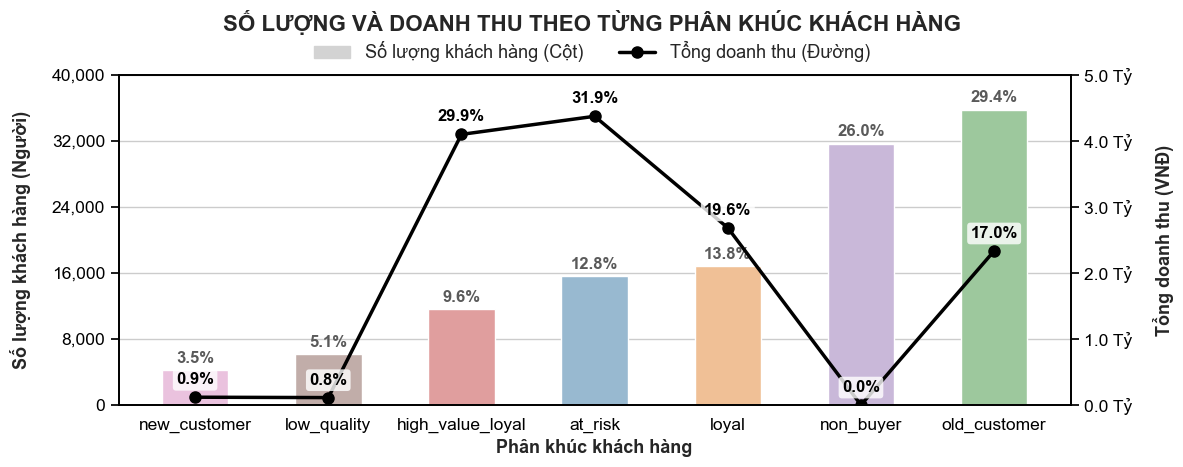

In [5272]:
# --- BƯỚC 1: CHUẨN BỊ, DỊCH THUẬT VÀ SẮP XẾP DỮ LIỆU ---
combo_df = df_customers.groupby('customer_segment', as_index=False).agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('actual_paid', 'sum')
)

# 1. Từ điển dịch tên phân khúc sang Tiếng Việt (Bạn có thể sửa lại theo ý thích)
segment_map = {
    'non_buyer': 'non_buyer',
    'new_customer': 'new_customer',
    'low_quality': 'low_quality',
    'at_risk': 'at_risk',
    'old_customer': 'old_customer',
    'loyal': 'loyal',
    'high_value_loyal': 'high_value_loyal'
}
# Áp dụng dịch sang Tiếng Việt cho cột customer_segment
combo_df['customer_segment'] = combo_df['customer_segment'].map(segment_map)

# 2. Cập nhật lại key của bảng màu (để Seaborn nhận diện đúng màu theo tên Tiếng Việt)
vn_segment_palette = {segment_map.get(k, k): v for k, v in segment_palette.items()}


total_customers = combo_df['customer_count'].sum()
total_revenue = combo_df['total_revenue'].sum()

combo_df['count_pct'] = (combo_df['customer_count'] / total_customers) * 100
combo_df['revenue_pct'] = (combo_df['total_revenue'] / total_revenue) * 100

# SẮP XẾP: Số lượng từ THẤP NHẤT đến CAO NHẤT
combo_df = combo_df.sort_values(by='customer_count', ascending=True).reset_index(drop=True)

# Ép kiểu về chuỗi (string)
combo_df['customer_segment'] = combo_df['customer_segment'].astype(str)
plot_order = combo_df['customer_segment'].tolist()


# --- BƯỚC 2: VẼ BIỂU ĐỒ ---
fig, ax1 = plt.subplots(figsize=(12, 5))
# Đổi tên biểu đồ sang Tiếng Việt
# plt.title('Sự đối lập giữa Số lượng và Doanh thu theo Phân khúc', fontsize=18, fontweight='bold', pad=20)

# 1. TRỤC Y BÊN TRÁI: VẼ CỘT (SỐ LƯỢNG)
sns.barplot(
    data=combo_df, 
    x='customer_segment', 
    y='customer_count', 
    hue='customer_segment',
    palette=vn_segment_palette, # Đã dùng bảng màu tên Tiếng Việt
    order=plot_order, 
    dodge=False, 
    legend=False,
    ax=ax1,
    width=0.5
)
ax1.set_ylabel('Số lượng khách hàng (Người)', fontsize=13, labelpad=15, fontweight='bold') # Thêm labelpad=15
ax1.set_xlabel('Phân khúc khách hàng', fontsize=13, fontweight='bold') # Đổi tên trục X

# 2. TRỤC Y BÊN PHẢI: VẼ ĐƯỜNG (DOANH THU)
ax2 = ax1.twinx()
ax2.plot(
    combo_df['customer_segment'], 
    combo_df['total_revenue'], 
    color='black', 
    marker='o',
    linewidth=2.5,
    markersize=8
)
ax2.set_ylabel('Tổng doanh thu (VNĐ)', fontsize=13, labelpad=15, fontweight='bold') # Thêm labelpad=15

# Đổi định dạng tiền: Từ "B" (Billion) sang "Tỷ"
def billions_formatter(x, pos):
    return f'{x / 1e9:.1f} Tỷ'
ax2.yaxis.set_major_formatter(FuncFormatter(billions_formatter))


# --- BƯỚC 3: XỬ LÝ ĐỒNG BỘ LƯỚI & SỐ CHẴN ---
ax2.grid(False) 

yticks_left = np.arange(0, 40001, 8000) 
yticks_right = np.arange(0, 5000000001, 1000000000)

ax1.set_yticks(yticks_left)
ax2.set_yticks(yticks_right)

ax1.set_ylim(0, 40000)
ax2.set_ylim(0, 5000000000)

# Định dạng trục Y bên trái có dấu phẩy
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))

# --- BƯỚC 4: GẮN NHÃN PHẦN TRĂM (%) ---
for p, pct in zip(ax1.patches, combo_df['count_pct']):
    height = p.get_height()
    if height > 0:
        ax1.text(p.get_x() + p.get_width() / 2., height + 500, 
                 f'{pct:.1f}%', ha='center', va='bottom', 
                 fontsize=12, color="#5A5A5A", fontweight='bold') # <-- Đã sửa màu và làm đậm

for i in range(len(combo_df)):
    rev = combo_df['total_revenue'].iloc[i]
    pct = combo_df['revenue_pct'].iloc[i]
    
    ax2.text(i, rev + 150000000, 
             f"{pct:.1f}%", ha='center', va='bottom', 
             fontsize=12, color='black', fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.2'))

# --- ÉP MÀU ĐEN CHO CÁC TRỤC TỌA ĐỘ VÀ CHỮ SỐ ---
# 1. Xử lý trục X và trục Y bên trái (ax1)
ax1.tick_params(axis='x', colors='black', labelsize=12.5) # Đổi màu chữ/vạch trục X
ax1.tick_params(axis='y', colors='black', labelsize=12.5) # Đổi màu chữ/vạch trục Y trái
for spine in ax1.spines.values():
    spine.set_color('black')              # Đổi màu đường viền khung ax1

# 2. Xử lý trục Y bên phải (ax2)
ax2.tick_params(axis='y', colors='black', labelsize=12.5) # Đổi màu chữ/vạch trục Y phải
for spine in ax2.spines.values():
    spine.set_color('black')              # Đổi màu đường viền khung ax2

# 1. Tạo hình đại diện cho Cột (Sử dụng màu xám trung tính đại diện chung cho các cột màu)
# Nếu bạn muốn dùng 1 màu cụ thể, hãy thay 'lightgray' bằng màu đó
column_proxy = mpatches.Patch(color='lightgray', label='Số lượng khách hàng (Cột)')

# 2. Tạo hình đại diện cho Đường (Đường màu đen, có chấm tròn ở giữa)
line_proxy = Line2D([0], [0], color='black', marker='o', linewidth=2.5, 
                    markersize=8, label='Tổng doanh thu (Đường)')

# 3. Chèn Legend vào phía trên biểu đồ (bbox_to_anchor giúp căn chỉnh vị trí thoáng hơn)
# 1. Đưa tiêu đề chính lên sát mép trên cùng (y=0.98)
fig.suptitle('SỐ LƯỢNG VÀ DOANH THU THEO TỪNG PHÂN KHÚC KHÁCH HÀNG', 
             fontsize=16, fontweight='bold', y=0.93)

# 2. Đưa Legend nằm ngay dưới tiêu đề chính (y=0.91)
# Giảm bbox_to_anchor xuống một chút để không chạm vào title
fig.legend(handles=[column_proxy, line_proxy], 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.9), 
           ncol=2, 
           fontsize=13, 
           frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.8)
plt.savefig('customer_seg.png', dpi=300, bbox_inches='tight')
plt.show()

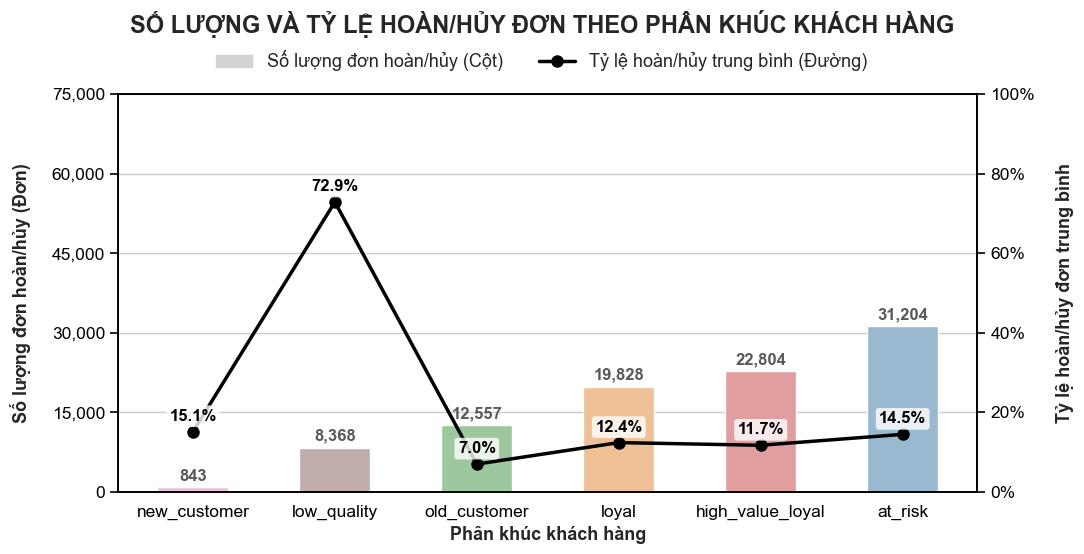

In [5273]:
# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---
# Tính tổng số đơn hoàn/hủy (cột) và trung bình tỷ lệ hoàn/hủy (đường)
df_buyers['total_return_cancel'] = df_buyers['return_order'] + df_buyers['cancel_order']

behavior_df = df_buyers.groupby('customer_segment', as_index=False).agg(
    total_rc=('total_return_cancel', 'sum'),
    avg_rate=('return_cancel_rate', 'mean')
)

# Sắp xếp theo số lượng đơn từ thấp đến cao
behavior_df = behavior_df.sort_values(by='total_rc', ascending=True).reset_index(drop=True)

# Chuyển tên phân khúc sang tiếng Việt (sử dụng segment_map đã có của bạn)
behavior_df['customer_segment'] = behavior_df['customer_segment'].map(segment_map).astype(str)
plot_order = behavior_df['customer_segment'].tolist()

# --- BƯỚC 2: VẼ BIỂU ĐỒ 2 TRỤC (DUAL-AXIS) ---
fig, ax1 = plt.subplots(figsize=(11, 6))

# Tiêu đề chính (In đậm, size 17, pad 20)
# plt.title('Sự đối lập giữa Số lượng đơn và Tỷ lệ Hoàn/Hủy theo Phân khúc', 
#           fontsize=17, fontweight='bold', pad=20)

# 1. TRỤC Y BÊN TRÁI: VẼ CỘT (TỔNG SỐ ĐƠN HOÀN/HỦY)
sns.barplot(
    data=behavior_df, 
    x='customer_segment', 
    y='total_rc', 
    hue='customer_segment',
    palette=vn_segment_palette, 
    order=plot_order,
    dodge=False, 
    legend=False,
    ax=ax1,
    width=0.5
)
ax1.set_ylabel('Số lượng đơn hoàn/hủy (Đơn)', fontsize=13, fontweight='bold', labelpad=15)
ax1.set_xlabel('Phân khúc khách hàng', fontsize=13, fontweight='bold')

# 2. TRỤC Y BÊN PHẢI: VẼ ĐƯỜNG (TỶ LỆ HOÀN/HỦY %)
ax2 = ax1.twinx()
ax2.plot(
    behavior_df['customer_segment'], 
    behavior_df['avg_rate'], 
    color='black', 
    marker='o',
    linewidth=2.5,
    markersize=8
)
ax2.set_ylabel('Tỷ lệ hoàn/hủy đơn trung bình', fontsize=13, fontweight='bold', labelpad=15)

# Format trục Y bên phải thành định dạng %
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

# --- BƯỚC 3: XỬ LÝ ĐỒNG BỘ LƯỚI & NỚI RỘNG THANG ĐO (Để hiện đủ 72.9%) ---
ax2.grid(False) 

# Chúng ta sẽ chia thành 6 mốc (5 khoảng)
# Trục trái (Số đơn): Bước nhảy 15,000 -> Max 75,000
yticks_left = np.array([0, 15000, 30000, 45000, 60000, 75000]) 

# Trục phải (Tỷ lệ %): Bước nhảy 20% -> Max 100% (Sẽ chứa được mốc 72.9% thoải mái)
yticks_right = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

ax1.set_yticks(yticks_left)
ax2.set_yticks(yticks_right)

# Thiết lập giới hạn trục mới
ax1.set_ylim(0, 75000)
ax2.set_ylim(0, 1.0)

# Định dạng trục Y bên trái có dấu phẩy
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))

# Giữ nguyên phần tô đen viền trục
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.2)
    ax.tick_params(axis='both', colors='black', width=1.2, labelsize=12.5)

# --- BƯỚC 4: GẮN NHÃN DỮ LIỆU ---
# Nhãn số lượng trên cột (màu xám đậm, in đậm)
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.text(p.get_x() + p.get_width() / 2., height + (75000 * 0.01), 
                 f'{int(height):,}', ha='center', va='bottom', 
                 fontsize=12, color="#5A5A5A", fontweight='bold')

# Nhãn % trên đường line (có khung nền trắng)
for i in range(len(behavior_df)):
    rate = behavior_df['avg_rate'].iloc[i]
    ax2.text(i, rate + (1.0 * 0.02), 
             f"{rate*100:.1f}%", ha='center', va='bottom', 
             fontsize=12, color='black', fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.2'))


# 1. Tạo hình đại diện cho Cột (Sử dụng màu xám trung tính đại diện chung cho các cột màu)
# Nếu bạn muốn dùng 1 màu cụ thể, hãy thay 'lightgray' bằng màu đó
column_proxy = mpatches.Patch(color='lightgray', label='Số lượng đơn hoàn/hủy (Cột)')

# 2. Tạo hình đại diện cho Đường (Đường màu đen, có chấm tròn ở giữa)
line_proxy = Line2D([0], [0], color='black', marker='o', linewidth=2.5, 
                    markersize=8, label='Tỷ lệ hoàn/hủy trung bình (Đường)')

# 3. Chèn Legend vào phía trên biểu đồ (bbox_to_anchor giúp căn chỉnh vị trí thoáng hơn)
# 1. Đưa tiêu đề chính lên sát mép trên cùng (y=0.98)
fig.suptitle('SỐ LƯỢNG VÀ TỶ LỆ HOÀN/HỦY ĐƠN THEO PHÂN KHÚC KHÁCH HÀNG', 
             fontsize=17, fontweight='bold', y=0.92)

# 2. Đưa Legend nằm ngay dưới tiêu đề chính (y=0.91)
# Giảm bbox_to_anchor xuống một chút để không chạm vào title
fig.legend(handles=[column_proxy, line_proxy], 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.88), 
           ncol=2, 
           fontsize=13, 
           frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.78)
fig.savefig('return_cancel.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

#### sub chart

In [5274]:
# ==========================================
# CÁC HÀM HỖ TRỢ FORMAT CHO STACKED BAR
# ==========================================

def apply_bar_standard_formatting(ax):
    """Áp dụng định dạng lưới, khung và trục chuẩn cho biểu đồ cột"""
    # Lưới ngang mờ, nằm dưới biểu đồ (zorder=0)
    ax.grid(True, axis='y', linestyle='-', color='#333333', alpha=0.2, zorder=0)
    ax.grid(False, axis='x') # Tắt lưới dọc cho đỡ rối mắt
    
    # Khung viền đen
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)
        
    # Format trục Y hiển thị % (0% - 100%)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylabel('Tỷ lệ (%)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Phân khúc khách hàng', fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', rotation=0, labelsize=13.5)

def add_percentage_labels(ax, threshold=0.04):
    """Gắn text % vào giữa các khối và TỰ ĐỘNG đổi màu chữ tương phản với nền"""
    for c in ax.containers:
        # Lấy màu nền của khối hiện tại (tuple RGBA)
        facecolor = c[0].get_facecolor()
        
        # Tính toán độ sáng (Luminance) của màu nền theo công thức chuẩn
        luminance = 0.299 * facecolor[0] + 0.587 * facecolor[1] + 0.114 * facecolor[2]
        
        # Nếu màu nền sáng (luminance > 0.6) thì dùng chữ Đen, ngược lại dùng chữ Trắng
        text_color = 'black' if luminance > 0.6 else 'white'
        
        # Tạo nhãn và gắn vào biểu đồ
        labels = [f'{w*100:.1f}%' if (w := v.get_height()) > threshold else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', color=text_color, fontweight='bold', fontsize=13)
        
# def add_percentage_labels(ax, threshold=0.04):
#     """Gắn text % vào giữa các khối. Ẩn các text nếu tỷ lệ < ngưỡng threshold để tránh chồng chéo"""
#     for c in ax.containers:
#         # Nếu chiều cao khối > ngưỡng (VD: 4%) thì hiện text, ngược lại để rỗng
#         labels = [f'{w*100:.1f}%' if (w := v.get_height()) > threshold else '' for v in c]
#         ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

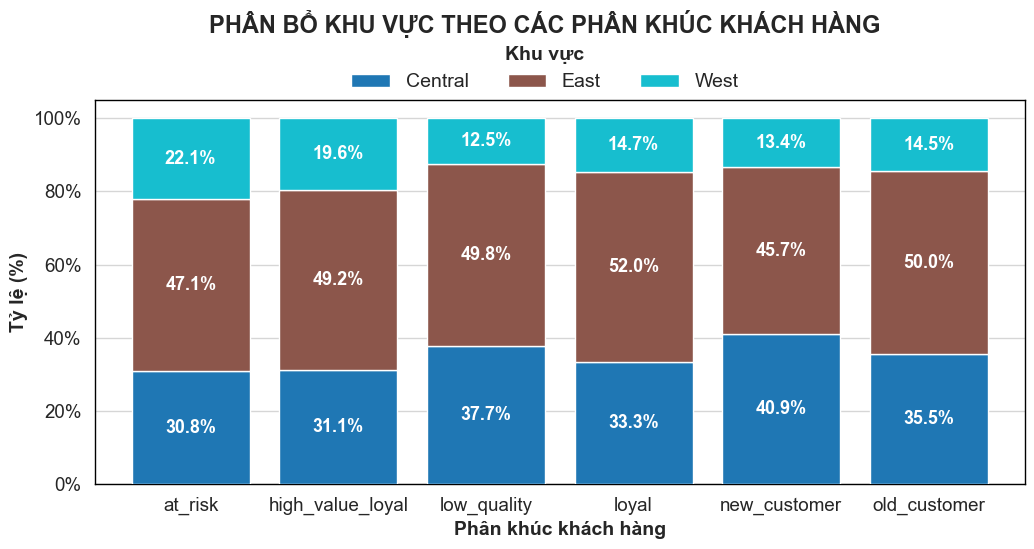

In [5275]:
# 1. Tính tỷ lệ %
crosstab_region = pd.crosstab(df_buyers['customer_segment'], df_buyers['region'], normalize='index')

# 2. Khởi tạo khung vẽ
fig, ax = plt.subplots(figsize=(12, 6))

# Vẽ biểu đồ stacked (zorder=3 để cột đè lên lưới)
crosstab_region.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white', width=0.8, zorder=3)

# 3. Trình bày & Định dạng chuẩn
apply_bar_standard_formatting(ax)
add_percentage_labels(ax)

fig.suptitle(f'PHÂN BỔ KHU VỰC THEO CÁC PHÂN KHÚC KHÁCH HÀNG', 
             fontsize=17, fontweight='bold', y=0.9)

# Đẩy Legend lên đầu, dàn ngang
ax.legend().remove() # Xóa legend mặc định
handles, labels = ax.get_legend_handles_labels()
leg = fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.87), 
                 ncol=len(labels), frameon=False, title='Khu vực', fontsize=14, title_fontsize=14)
leg.get_title().set_fontweight('bold')

# Dịch khung đồ thị xuống để nhường chỗ cho Legend
plt.subplots_adjust(top=0.75)

fig.savefig('region_seg.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

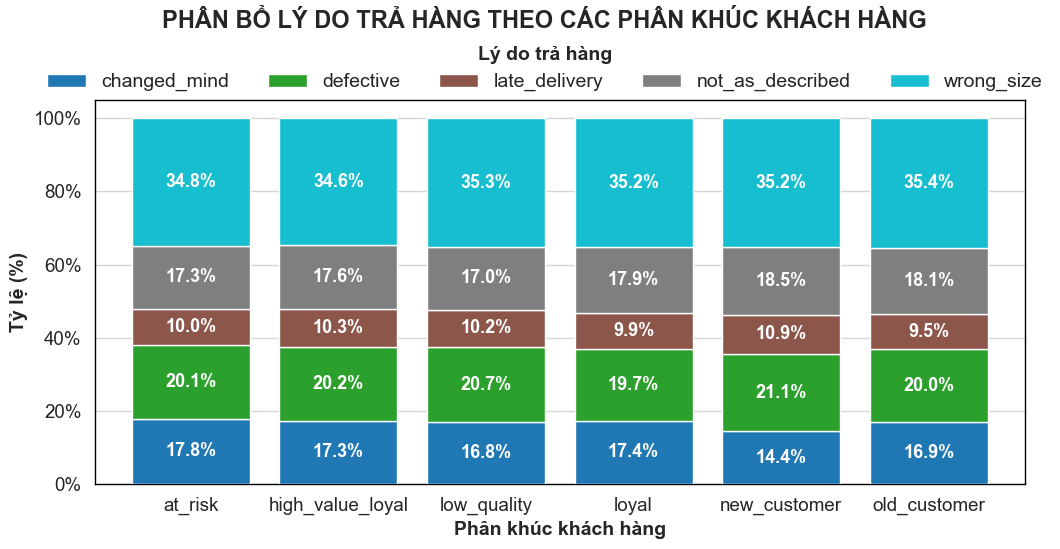

In [5276]:
# 1. Làm sạch dữ liệu
df_returns_clean = df_returns[df_returns['customer_segment'] != 'non_buyer'].copy()
if hasattr(df_returns_clean['customer_segment'], 'cat'):
    df_returns_clean['customer_segment'] = df_returns_clean['customer_segment'].cat.remove_unused_categories()

# Tính tỷ lệ %
crosstab_return = pd.crosstab(df_returns_clean['customer_segment'], df_returns_clean['return_reason'], normalize='index')

# 2. Khởi tạo khung vẽ
fig, ax = plt.subplots(figsize=(12, 6))

# Vẽ biểu đồ stacked
crosstab_return.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white', width=0.8, zorder=3)

# 3. Trình bày & Định dạng chuẩn
apply_bar_standard_formatting(ax)
add_percentage_labels(ax)

fig.suptitle(f'PHÂN BỔ LÝ DO TRẢ HÀNG THEO CÁC PHÂN KHÚC KHÁCH HÀNG', 
             fontsize=17, fontweight='bold', y=0.9)

# Đẩy Legend lên đầu, dàn ngang (ncol tùy chỉnh theo số lý do đổi trả)
ax.legend().remove()
handles, labels = ax.get_legend_handles_labels()
leg = fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.87), 
                 ncol=len(labels), frameon=False, title='Lý do trả hàng', fontsize=14, title_fontsize=14)
leg.get_title().set_fontweight('bold')

plt.subplots_adjust(top=0.75)

fig.savefig('reason_seg.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

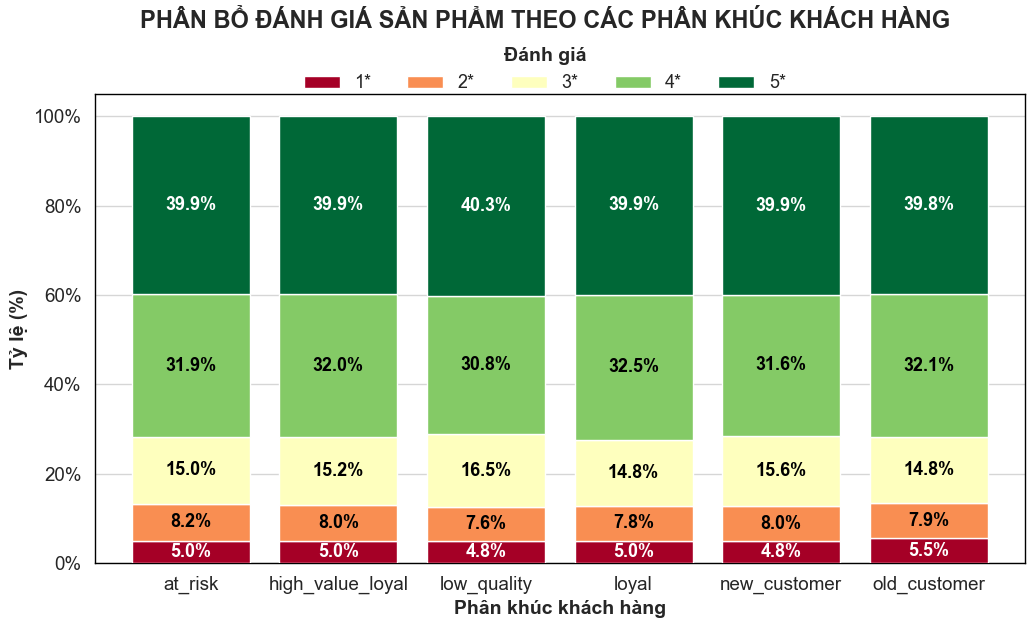

In [5277]:
# 1. Làm sạch dữ liệu
df_reviews_clean = df_reviews[df_reviews['customer_segment'] != 'non_buyer'].copy()
if hasattr(df_reviews_clean['customer_segment'], 'cat'):
    df_reviews_clean['customer_segment'] = df_reviews_clean['customer_segment'].cat.remove_unused_categories()

# Tính tỷ lệ %
crosstab_review = pd.crosstab(df_reviews_clean['customer_segment'], df_reviews_clean['rating'], normalize='index')

# 2. Khởi tạo khung vẽ
fig, ax = plt.subplots(figsize=(12, 7))

# Vẽ biểu đồ stacked
crosstab_review.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn', edgecolor='white', width=0.8, zorder=3)

# 3. Trình bày & Định dạng chuẩn
apply_bar_standard_formatting(ax)
add_percentage_labels(ax)

fig.suptitle(f'PHÂN BỔ ĐÁNH GIÁ SẢN PHẨM THEO CÁC PHÂN KHÚC KHÁCH HÀNG', 
             fontsize=17, fontweight='bold', y=0.9)

# Đẩy Legend lên đầu, dàn ngang
ax.legend().remove()
handles, labels = ax.get_legend_handles_labels()
# Thêm hậu tố "Sao" hoặc "*" nếu bạn muốn rõ nghĩa hơn (Tùy chọn: labels = [f"{l}*" for l in labels])
leg = fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.87), 
                 ncol=len(labels), frameon=False, title='Đánh giá', fontsize=13, title_fontsize=14)
leg.get_title().set_fontweight('bold')

plt.subplots_adjust(top=0.78)
fig.savefig('rating_seg.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### 3.3. Bi-weekly Transaction & Revenue Trends
Analyzing long-term transaction and revenue patterns across different customer segments. We apply a bi-weekly resampling interval to smooth out daily volatility while preserving macro trends over a 10-year period.

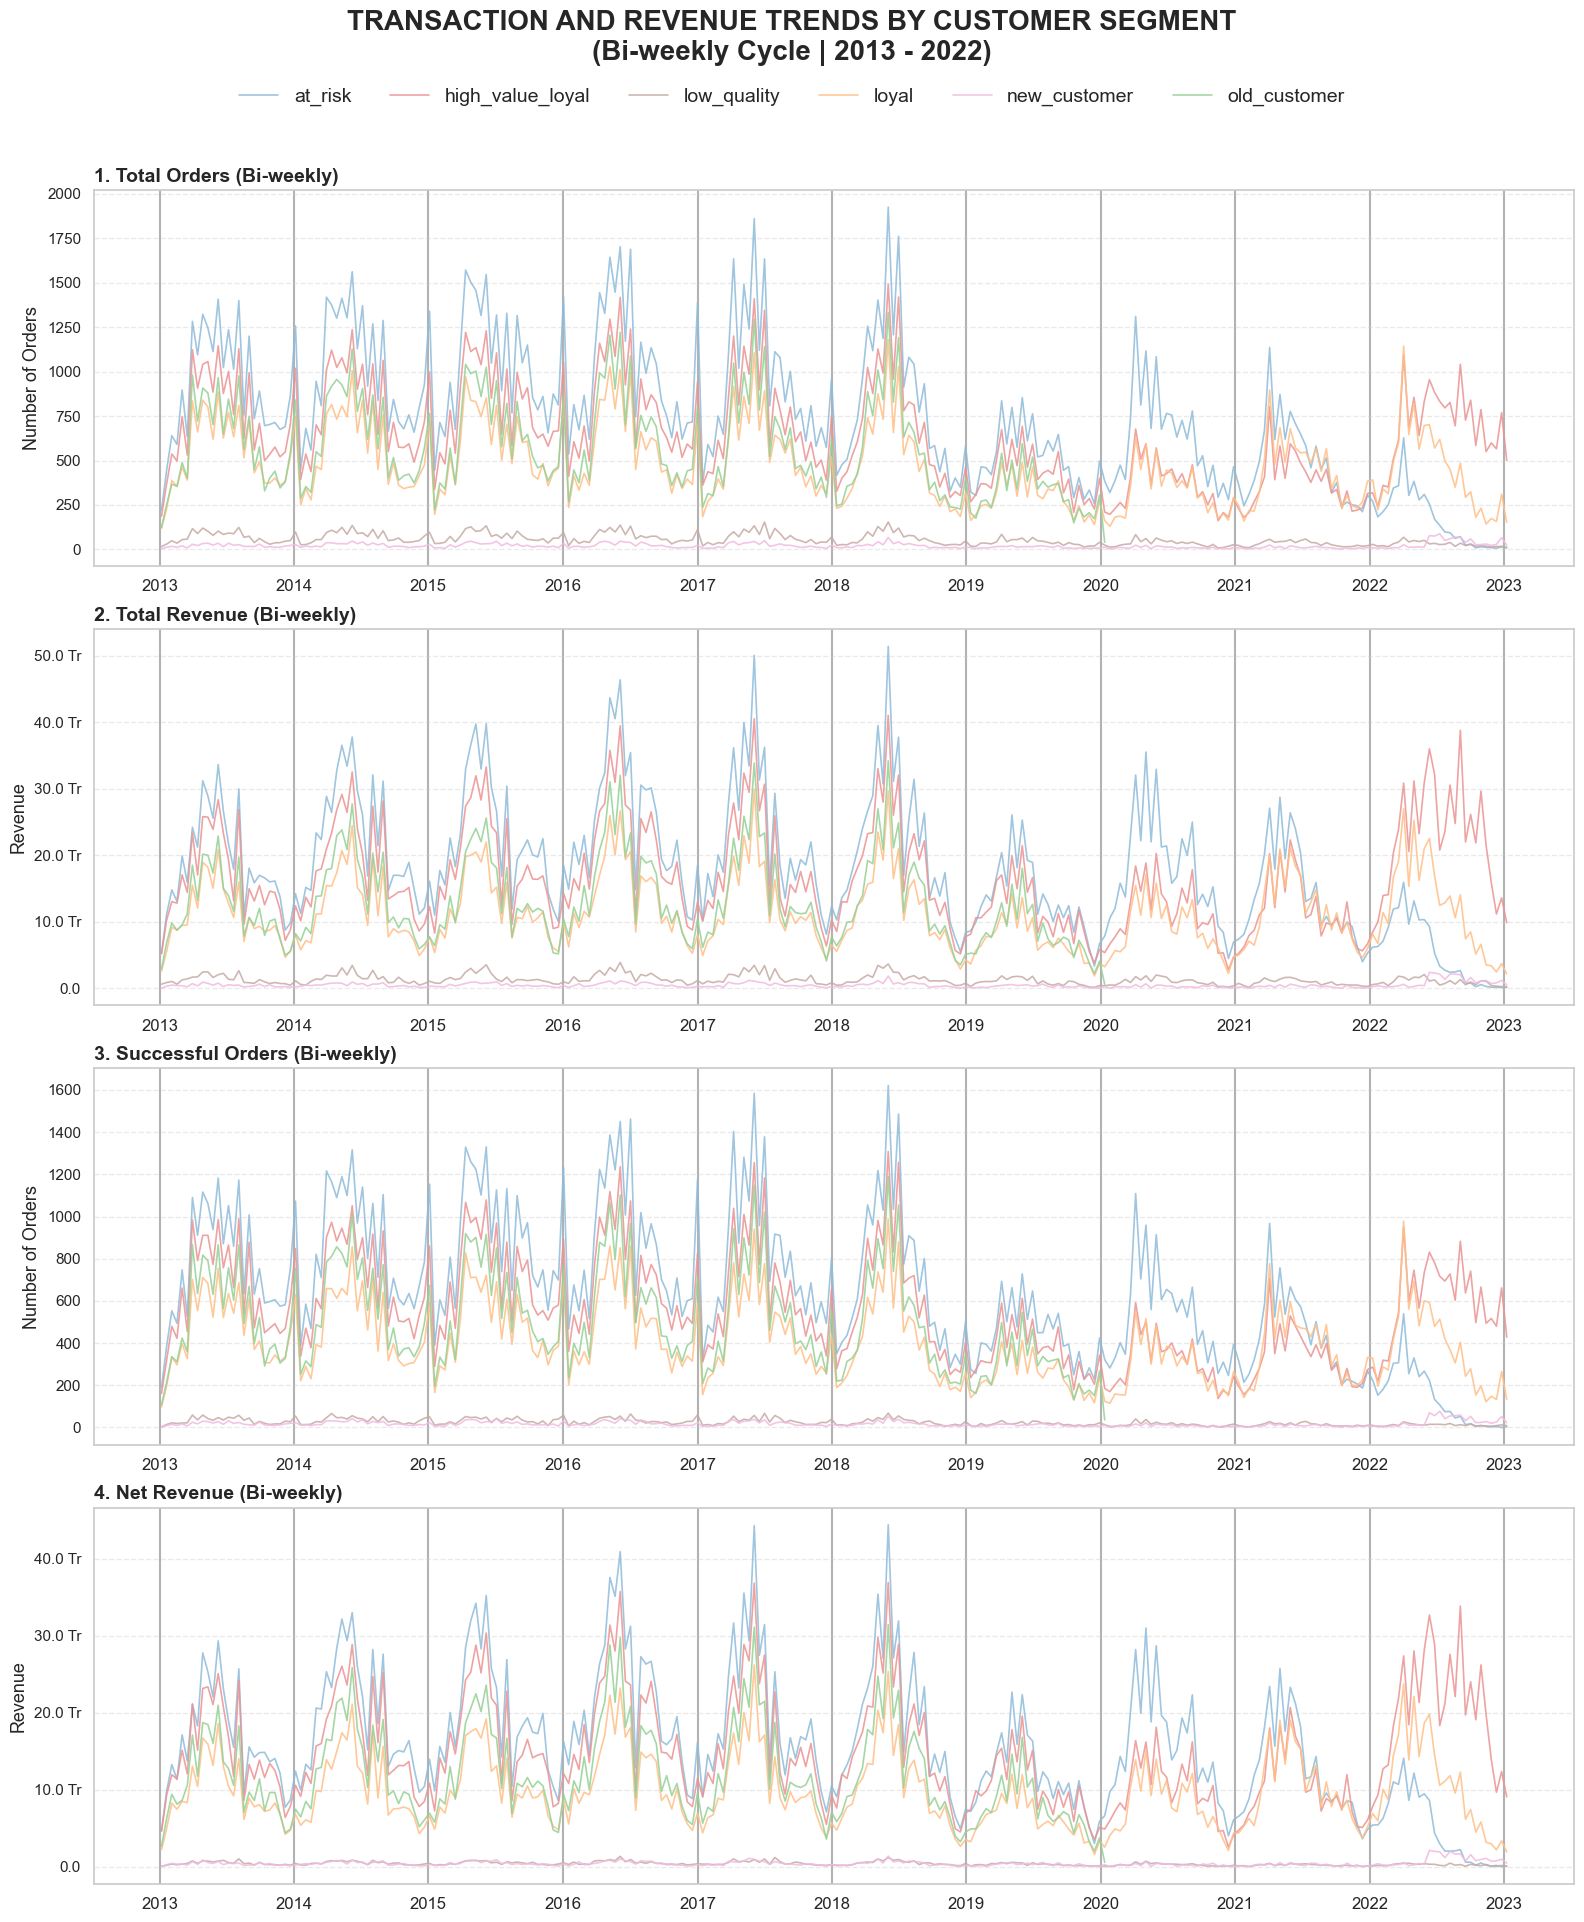

In [5278]:
# Define timeframe for long-term trend analysis
start_date = '2013-01-01'
end_date = '2022-12-31'

# Customize vertical grid lines to mark yearly boundaries
year_grid_linewidth = 1.5   # Độ dày
year_grid_alpha = 0.6       # Độ đậm
year_grid_color = 'gray'    # Màu 

# Filter data within the specified timeframe
filtered_df = daily_segment_df[
    (daily_segment_df['order_date'] >= start_date) & 
    (daily_segment_df['order_date'] <= end_date)
].copy()
filtered_df['customer_segment'] = filtered_df['customer_segment'].cat.remove_unused_categories()

# Resample data to a bi-weekly ('2W') cycle and sum the metrics
biweekly_df = filtered_df.set_index('order_date') \
    .groupby('customer_segment', observed=True) \
    .resample('2W').sum().reset_index()

# Initialize a 4x1 subplot grid sharing the X-axis
fig, axes = plt.subplots(4, 1, figsize=(16, 20), sharex=True)
fig.suptitle(f'TRANSACTION AND REVENUE TRENDS BY CUSTOMER SEGMENT\n(Bi-weekly Cycle | {start_date[:4]} - {end_date[:4]})', 
             fontsize=20, fontweight='bold', y=0.96)

metrics = ['total_order', 'total_paid', 'actual_order', 'actual_paid']
titles = [
    '1. Total Orders (Bi-weekly)',
    '2. Total Revenue (Bi-weekly)',
    '3. Successful Orders (Bi-weekly)',
    '4. Net Revenue (Bi-weekly)',
]
ylabels = ['Number of Orders', 'Revenue', 'Number of Orders', 'Revenue']

for i, ax in enumerate(axes):
    sns.lineplot(
        data=biweekly_df,
        x='order_date',
        y=metrics[i],
        hue='customer_segment',
        palette=segment_palette,
        linewidth=1.2,
        alpha=0.85,
        ax=ax,
        legend=(i == 0)
    )
    ax.set_title(titles[i], fontsize=14, fontweight='bold', loc='left')
    ax.set_ylabel(ylabels[i], fontsize=13)
    ax.set_xlabel('')
    
    # Configure grid lines
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.grid(True, axis='x', linestyle='-', color=year_grid_color, linewidth=year_grid_linewidth, alpha=year_grid_alpha)
            
    # Apply currency formatter for revenue subplots
    if i in [1, 3]:
        ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
    
    # Extract legend handles from the first subplot and remove its localized legend
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

# Format X-axis to display only the Year
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=0, labelsize=12, labelbottom=True)

# Create a centralized legend at the top of the figure
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=7, fontsize=14, frameon=False)

plt.tight_layout()
# Adjust top spacing to prevent Suptitle and Legend from overlapping with plots
plt.subplots_adjust(top=0.87) 
plt.show()

In [5279]:
# Define segment names and map them to a Seaborn palette
segment_names = [
    'at_risk', 'loyal', 'old_customer', 
    'high_value_loyal', 'non_buyer', 'low_quality', 'new_customer'
]

# segment_names = [
#     'many_order', 'little_order', 'non_buyer'
# ]

tab10_colors = sns.color_palette("tab10", len(segment_names))
segment_palette = dict(zip(segment_names, tab10_colors))

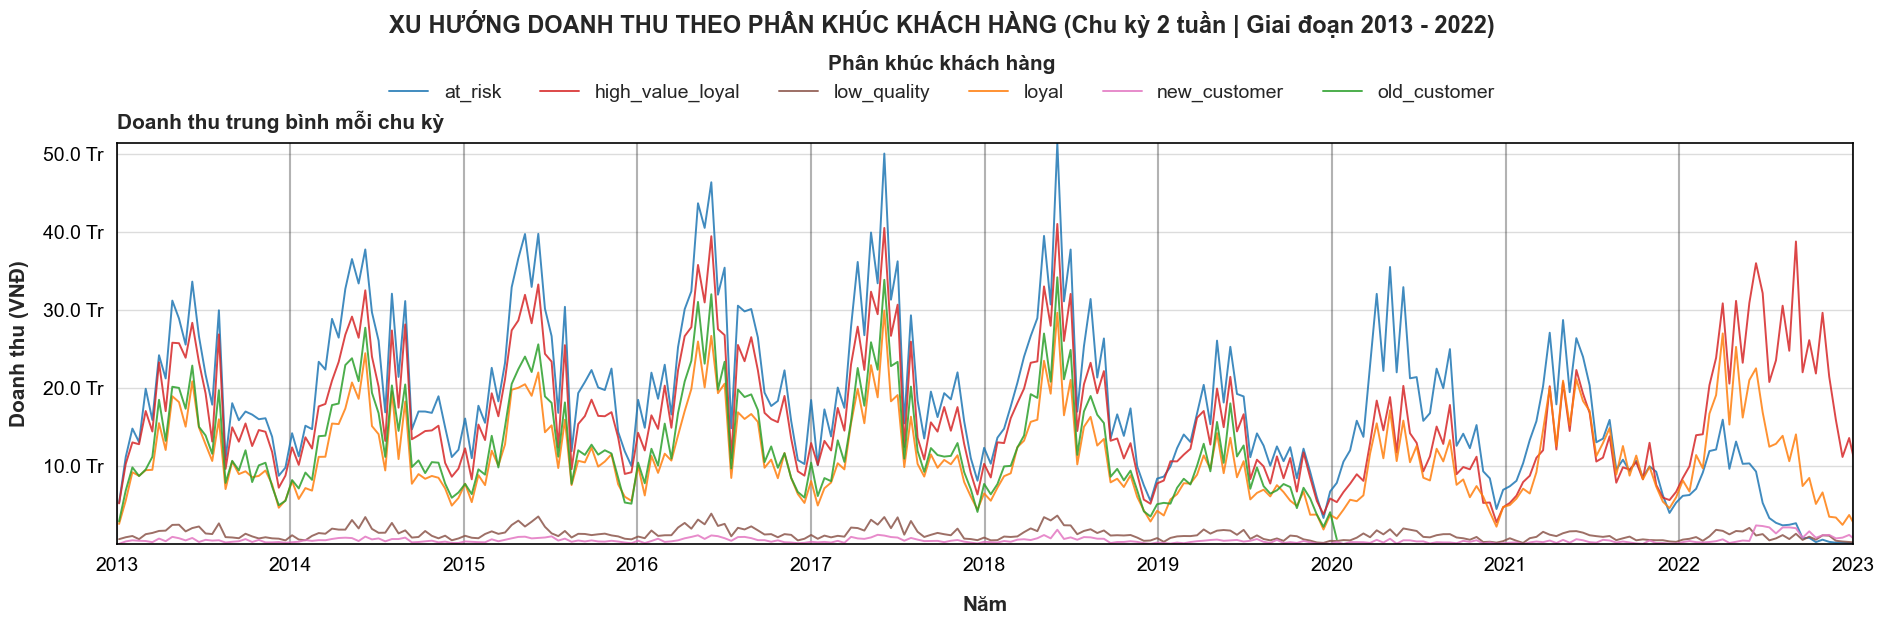

In [5280]:
# 1. Khởi tạo khung vẽ
fig, ax = plt.subplots(figsize=(19, 7))

# 2. Dịch tên phân khúc sang tiếng Việt (Tạo mapping)
# Lưu ý: Tôi đổi 'loyal' thành 'Khách mua thưa thớt' theo logic phân tích ở bước trước. 
# Bạn có thể tự chỉnh lại nếu muốn.
segment_translation = {
    'non_buyer': 'non_buyer',
    'new_customer': 'new_customer',
    'low_quality': 'low_quality',
    'at_risk': 'at_risk',
    'old_customer': 'old_customer',
    'loyal': 'loyal',
    'high_value_loyal': 'high_value_loyal'
}

# Tạo một cột tạm thời trong DataFrame để vẽ chart tiếng Việt
biweekly_df['segment_vn'] = biweekly_df['customer_segment'].map(segment_translation)

# Cập nhật lại palette màu theo tên tiếng Việt
palette_vn = {segment_translation[k]: v for k, v in segment_palette.items() if k in segment_translation}

# 3. Vẽ đường Lineplot
sns.lineplot(
    data=biweekly_df,
    x='order_date',
    y='total_paid',
    hue='segment_vn',      # Sử dụng cột tiếng Việt
    palette=palette_vn,    # Sử dụng bảng màu đã mapping
    linewidth=1.4,
    alpha=0.85,
    ax=ax
)
# 4. Tạo Tiêu đề chính (Dùng fig.suptitle để neo thẳng lên nóc Figure)
fig.suptitle(f'XU HƯỚNG DOANH THU THEO PHÂN KHÚC KHÁCH HÀNG (Chu kỳ 2 tuần | Giai đoạn {start_date[:4]} - {end_date[:4]})',
             fontsize=17, fontweight='bold', y=0.89)

# 5. Xử lý Chú thích (Legend)
handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove() # Xóa chú thích mặc định

# Neo Legend vào Figure thay vì ax, đặt ở vị trí 88% chiều cao (dưới Tiêu đề chính một chút)
# 1. Gán lệnh tạo legend vào biến 'leg'
leg = fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.85), 
                 ncol=6, fontsize=14, frameon=False, 
                 title="Phân khúc khách hàng", title_fontsize=15)

# 2. Gọi lệnh in đậm cho tiêu đề của biến 'leg' đó
leg.get_title().set_fontweight('bold')

# 6. Định dạng TRỤC Y và Tiêu đề phụ (Subtitle)
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.set_ylabel('Doanh thu (VNĐ)', fontsize=15, fontweight='bold', labelpad=10)
# Tiêu đề phụ chỉ cần khoảng cách pad=10 là đủ đẹp
ax.set_title('Doanh thu trung bình mỗi chu kỳ', fontsize=15, fontweight='bold', loc='left', pad=10)
# 7. Định dạng TRỤC X
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=0, labelsize=14)
ax.set_xlabel('Năm', fontsize=15, fontweight='bold', labelpad=15)

# BỎ DÒNG NÀY:
# ax.margins(x=0) 

# THÊM DÒNG NÀY: Ép giới hạn trục X bắt đầu đúng từ 01/01/2013
ax.set_xlim(pd.to_datetime('2013-01-01'), pd.to_datetime('2023-01-01'))


# 8. Kẻ lưới
ax.grid(True, axis='y', linestyle='-', color='#333333', alpha=0.17)
ax.grid(True, axis='x', linestyle='-', color=year_grid_color, linewidth=year_grid_linewidth, alpha=year_grid_alpha)


# 8.5. TÔ ĐEN VÀ LÀM ĐẬM TRỤC X, Y
for spine in ax.spines.values():
    spine.set_color('black')      # Chuyển viền thành màu đen
    spine.set_linewidth(1.2)      # Tăng độ dày viền lên một chút cho sắc nét

# Đổi màu đen cho cả các vạch chia (ticks)
ax.tick_params(axis='both', colors='black', width=1.2, labelsize=14)
ax.margins(y=0)
# 9. Căn chỉnh bố cục tự động
# XÓA plt.subplots_adjust(top=0.68)
# Dùng tham số rect=[left, bottom, right, top] để giới hạn không gian biểu đồ từ 0 -> 83% chiều cao,
# chừa lại 17% phía trên cùng khoảng trống cho suptitle và legend thở.
plt.tight_layout(rect=[0, 0, 1, 0.83])
plt.subplots_adjust(top=0.7)
plt.savefig('yearly_avg.png', dpi=300, bbox_inches='tight')
plt.show()

#### INSIGHTS & BUSINESS IMPLICATIONS
- **Visual Context**: A 10-year bi-weekly trend analysis that filters out daily noise, allowing us to observe the business's long-term resilience and growth trajectory.
- **Key Findings**:
    - **Cyclical Growth**: Revenue spikes occur at highly predictable intervals throughout the year, followed by deep retreats to a baseline level.
    - **The Loyal Buffer**: During market downturns or "trough" months between major sales, the baseline revenue is almost entirely sustained by the `loyal` and `high_value_loyal` segments, acting as a shock absorber.
- **Actionable Recommendations**:
    - **OpEx Planning**: Operational expenditures (OpEx) should be benchmarked against the baseline revenue generated by loyal segments, rather than the annual average (which is heavily skewed by seasonal peaks).
    - **Cash Flow Management**: The deep valleys between spikes are high-risk periods for liquidity. The business must optimize inventory turnover and maintain working capital reserves for these off-peak months.

### 3.4. Seasonality Analysis (Daily Averages)
To isolate and identify annual seasonal patterns (e.g., peak shopping seasons, holiday drops), we aggregate the daily metrics across a recent 5-year period (2018-2022) and map them onto a single "dummy" year for continuous overlapping visualization.

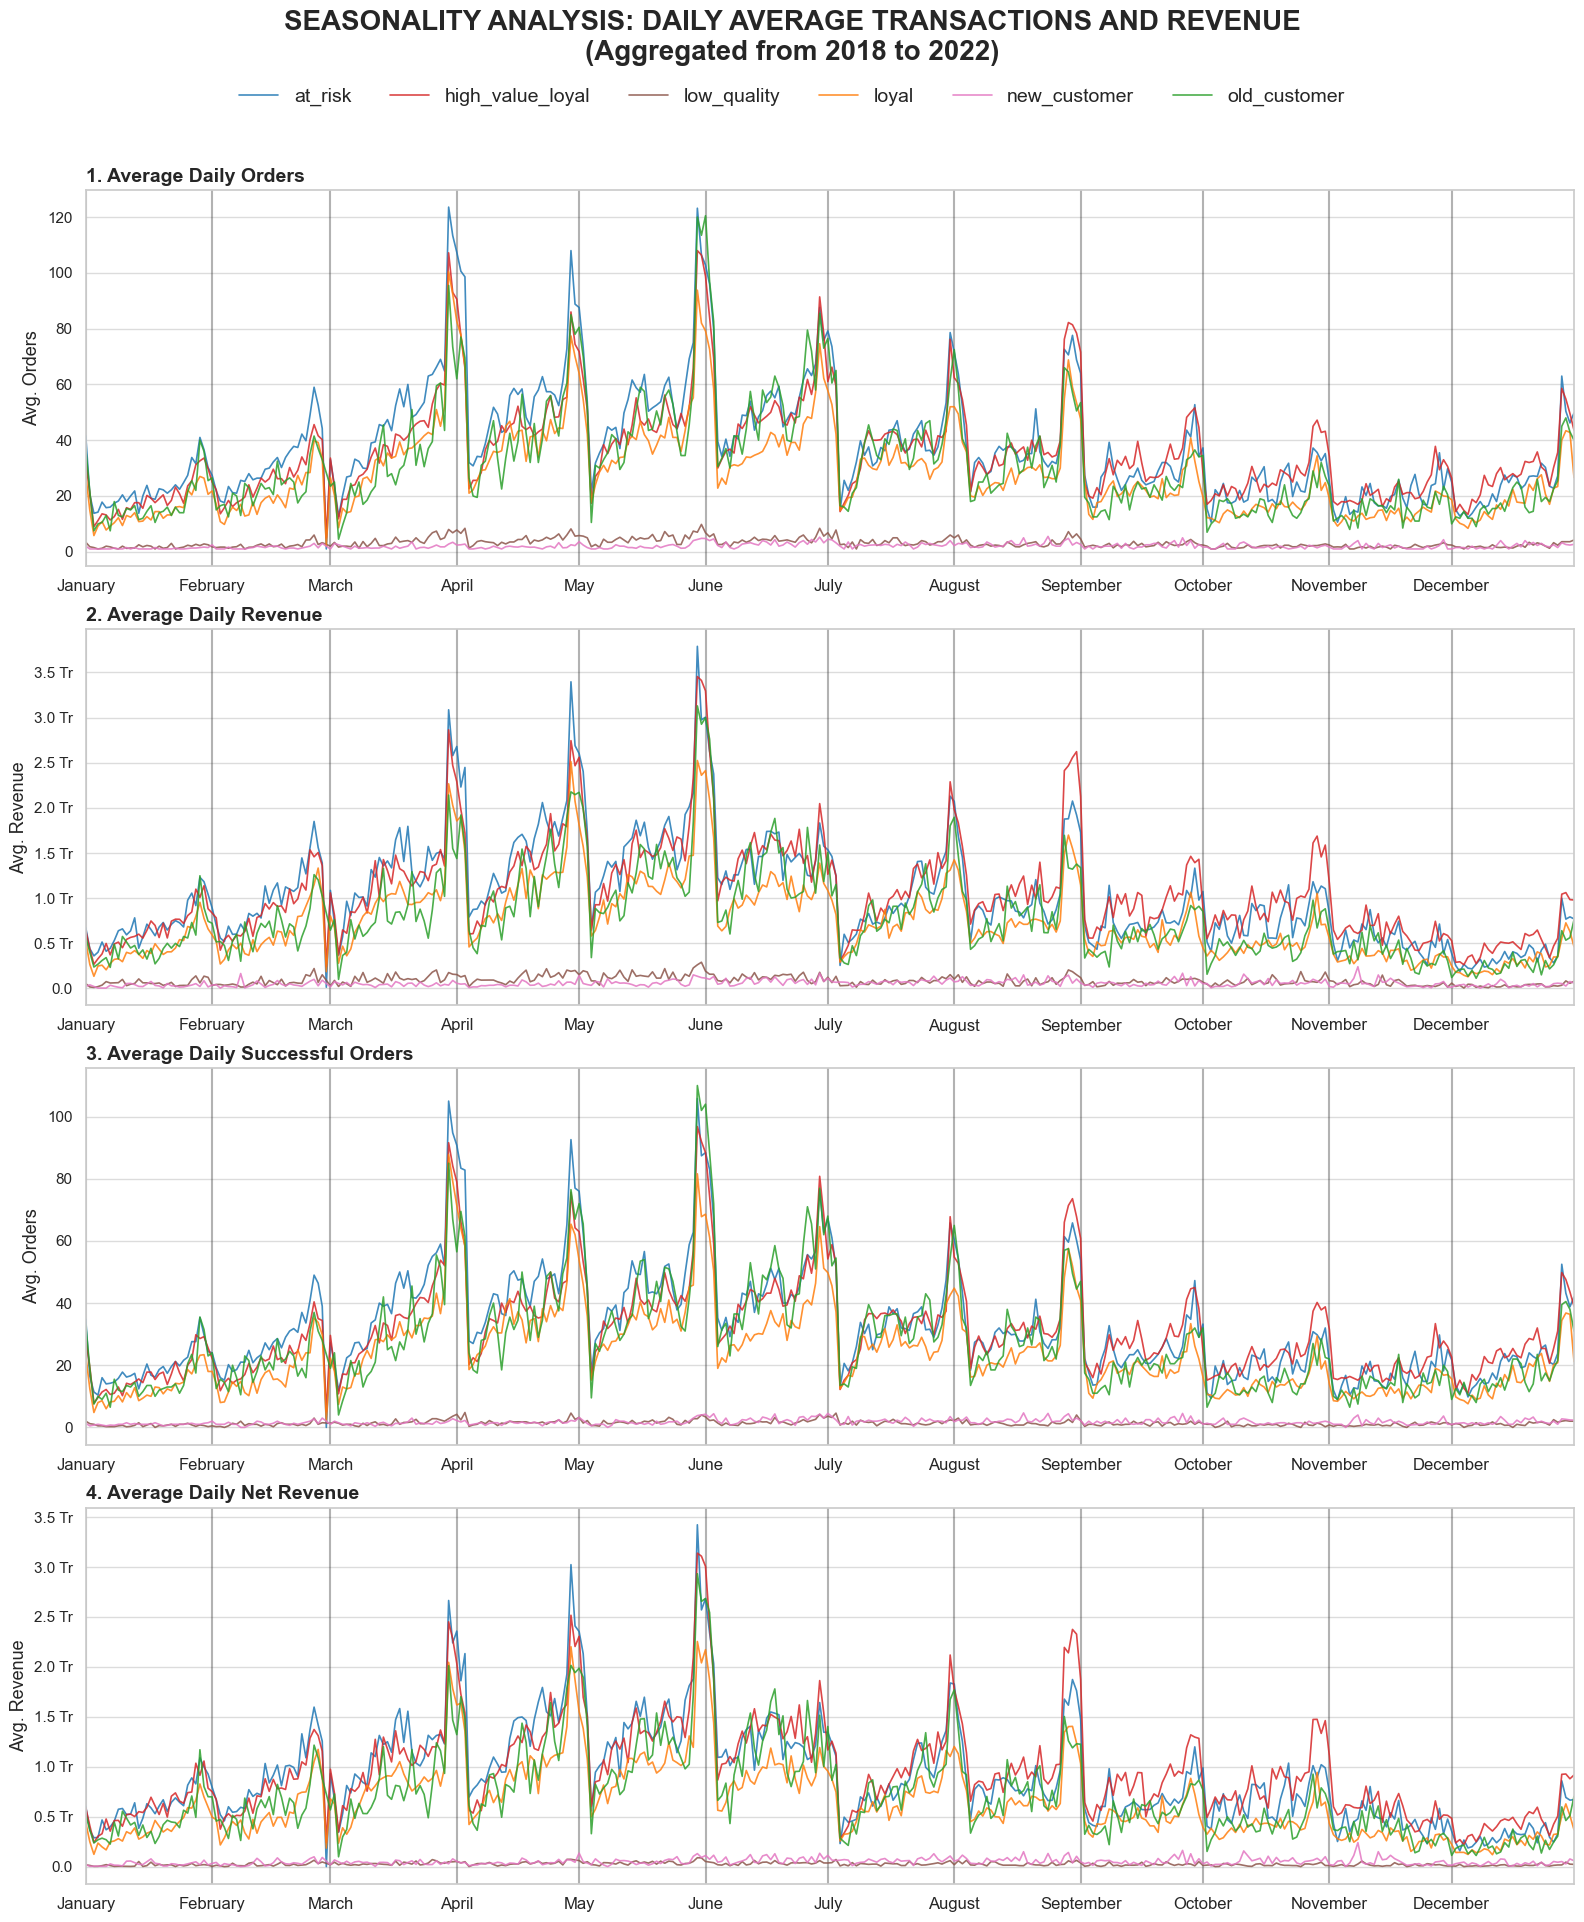

In [5281]:
# Define timeframe for recent seasonality analysis
start_date = '2018-01-01'
end_date = '2022-12-31'

# Customize vertical grid lines to mark monthly boundaries
month_grid_linewidth = 1.5   # Độ dày
month_grid_alpha = 0.6       # Độ đậm
month_grid_color = 'gray'    # Màu   

# Filter data within the specified timeframe
filtered_df = daily_segment_df[
    (daily_segment_df['order_date'] >= start_date) & 
    (daily_segment_df['order_date'] <= end_date)
].copy()
filtered_df['customer_segment'] = filtered_df['customer_segment'].cat.remove_unused_categories()

# Extract Month-Day and map it to a leap dummy year (2020) to plot continuously on a single X-axis
filtered_df['month_day'] = filtered_df['order_date'].dt.strftime('%m-%d')
filtered_df['dummy_date'] = pd.to_datetime('2020-' + filtered_df['month_day'], errors='coerce')

# Aggregate the metrics by calculating the MEAN for each day of the year across all analyzed years
seasonality_df = filtered_df.groupby(['dummy_date', 'customer_segment'], observed=True)[
    ['total_order', 'total_paid', 'actual_order', 'actual_paid']
].mean().reset_index()

# Initialize a 4x1 subplot grid
fig, axes = plt.subplots(4, 1, figsize=(16, 20), sharex=True)
fig.suptitle(f'SEASONALITY ANALYSIS: DAILY AVERAGE TRANSACTIONS AND REVENUE\n(Aggregated from {start_date[:4]} to {end_date[:4]})', 
             fontsize=20, fontweight='bold', y=0.96)

metrics = ['total_order', 'total_paid', 'actual_order', 'actual_paid']
titles = [
    '1. Average Daily Orders',
    '2. Average Daily Revenue',
    '3. Average Daily Successful Orders',
    '4. Average Daily Net Revenue',
]
ylabels = ['Avg. Orders', 'Avg. Revenue', 'Avg. Orders', 'Avg. Revenue']

for i, ax in enumerate(axes):
    sns.lineplot(
        data=seasonality_df,
        x='dummy_date',
        y=metrics[i],
        hue='customer_segment',
        palette=segment_palette,
        linewidth=1.2, 
        alpha=0.85,
        ax=ax,
        legend=(i == 0) 
    )
    
    ax.set_title(titles[i], fontsize=14, fontweight='bold', loc='left')
    ax.set_ylabel(ylabels[i], fontsize=13)
    ax.set_xlabel('')
    
    # Configure grid lines
    ax.grid(True, axis='y', linestyle='-', color='#333333', alpha=0.17)
    ax.grid(True, axis='x', linestyle='-', color=month_grid_color, linewidth=month_grid_linewidth, alpha=month_grid_alpha)

    # Apply currency formatter     
    if i in [1, 3]:
        ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
        
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

# Format X-axis to display abbreviated English Month names at the start of each month
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
    ax.tick_params(axis='x', rotation=0, labelsize=12, labelbottom=True)
    # Limit the X-axis strictly from Jan 1st to Dec 31st 
    ax.set_xlim([pd.to_datetime('2020-01-01'), pd.to_datetime('2020-12-31')])

# Create centralized legend
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=7, fontsize=14, frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.87) 
plt.show()

#### INSIGHTS & BUSINESS IMPLICATIONS
- **Visual Context**: By overlapping 5 years of daily metrics onto a single dummy year, we can clearly identify the market's natural purchasing rhythm.
- **Key Findings**:
    - **Coordinated Peaks**: There is a synchronized surge across all customer segments during specific months (noticeably around March, June, August, and year-end).
    - **The Impulse Gap**: During peak seasons, the gap between "Total Orders" and "Successful Orders" widens significantly. This indicates impulsive buying behavior driven by FOMO, leading to higher cancellation or return rates shortly after.
- **Actionable Recommendations**:
    - **Supply Chain Readiness**: Warehouse staffing and safety stock must reach maximum capacity at least 2-3 weeks before these identifiable peaks to prevent out-of-stock revenue loss.
    - **Budget Allocation**: Stop spreading the marketing budget evenly across 12 months. Shift to a "Pulse Marketing" strategy—injecting heavy ad spend right before and during peak zones to maximize Conversion Rates.

### 3.5. Promotion Lifecycle & Distribution Analysis
Visualizing the distribution of promotional campaigns across different months and durations to identify operational patterns. We use a custom jittered bubble chart to prevent data overlap and a Gantt chart to map the standard annual promotion timeframe.

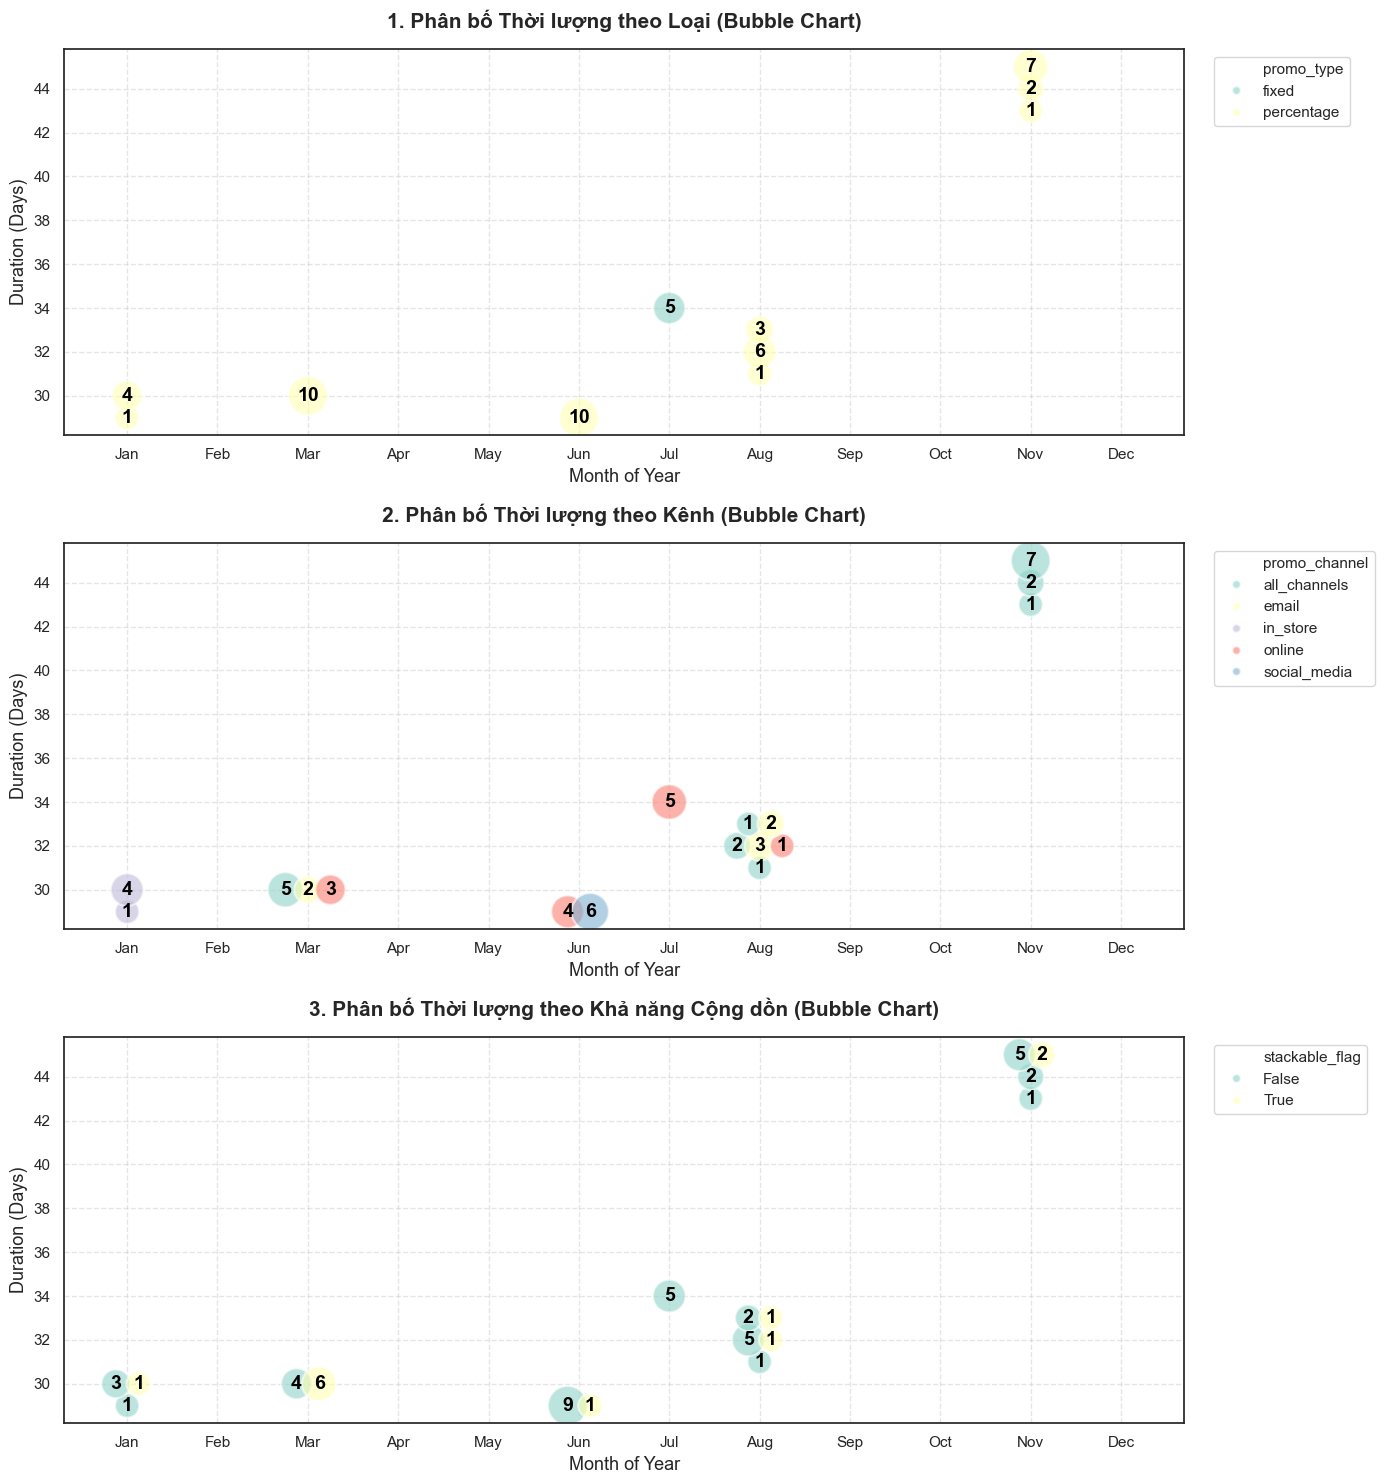

In [5282]:
def draw_bubble_chart_optimized(ax, data, hue_column, title):
    # 1. Aggregate data (Remove zero-count groups)
    df_agg = data.groupby(['month', 'duration_days', hue_column]).size().reset_index(name='promo_count')
    df_agg = df_agg[df_agg['promo_count'] > 0].copy()

    # 2. JITTERING PROCESS: Slightly shift X-coordinates to prevent overlapping bubbles
    df_agg['group_size'] = df_agg.groupby(['month', 'duration_days'])['month'].transform('size')
    # Rank identical overlapping bubbles
    df_agg['rank'] = df_agg.groupby(['month', 'duration_days']).cumcount()

    # Calculate new X-coordinate (Offset from the base month)
    spacing = 0.25
    df_agg['month_jittered'] = df_agg['month'] + (df_agg['rank'] - (df_agg['group_size'] - 1) / 2) * spacing

    # 3. Draw the bubble chart using the jittered X-axis
    sns.scatterplot(
        data=df_agg,
        x='month_jittered',
        y='duration_days',
        hue=hue_column,
        size='promo_count',
        sizes=(300, 800), # bubble sizes
        alpha=0.6,
        edgecolor='white',
        linewidth=1.5,
        ax=ax,
        palette='Set3' 
    )

    # 4. Annotate the exact count inside EACH separated bubble
    for _, row in df_agg.iterrows():
        ax.text(
            row['month_jittered'],
            row['duration_days'],
            str(int(row['promo_count'])),
            color='black',
            ha='center', va='center',
            fontsize=14, 
            fontweight='bold',
        )

    # 5. Layout Presentation
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Month of Year', fontsize=13)
    ax.set_ylabel('Duration (Days)', fontsize=13)

    # Force X-axis to display exact months (1 -> 12) despite the jittering
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([calendar.month_abbr[i] for i in range(1, 13)])
    # Expand X-axis limits slightly to prevent edge bubbles from being cropped
    ax.set_xlim(0.3, 12.7) 

    # Clean up the Legend
    handles, labels = ax.get_legend_handles_labels()
    # Find the index of 'promo_count' to strip size instructions, keeping only color keys
    cut_idx = labels.index('promo_count') if 'promo_count' in labels else len(labels)
    ax.legend(handles[:cut_idx], labels[:cut_idx], bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)
    
sns.set_theme(style="white")
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

draw_bubble_chart_optimized(axes[0], df_promotions, 'promo_type', '1. Phân bố Thời lượng theo Loại (Bubble Chart)')
draw_bubble_chart_optimized(axes[1], df_promotions, 'promo_channel', '2. Phân bố Thời lượng theo Kênh (Bubble Chart)')
draw_bubble_chart_optimized(axes[2], df_promotions, 'stackable_flag', '3. Phân bố Thời lượng theo Khả năng Cộng dồn (Bubble Chart)')

plt.tight_layout()
plt.show()

#### Standard Annual Promotion Calendar Visualization

In [5283]:
# ==========================================
# 1. THÔNG SỐ CƠ BẢN & TỪ ĐIỂN
# ==========================================
start_date = '2013-01-01'
end_date = '2022-12-31'
dummy_year = 2020

# Cấu hình lưới chuẩn
GRID_CONFIG = {'linewidth': 1.5, 'alpha': 0.6, 'color': 'gray'}

# Từ điển chiến dịch chuẩn (Lưu ý chữ thường/hoa để tránh KeyError)
ALL_CAMPAIGNS = ['Rural Special', 'Spring Sale', 'Mid-year Sale', 'Urban Blowout', 'Fall Launch', 'Year-End Sale']
camp_colors = sns.color_palette('Set2', len(ALL_CAMPAIGNS))
camp_palette = dict(zip(ALL_CAMPAIGNS, camp_colors))

campaign_vn = {
    'Rural Special': 'Rural Special',
    'Spring Sale': 'Spring Sale',
    'Mid-year Sale': 'Mid-year Sale',
    'Urban Blowout': 'Urban Blowout',
    'Fall Launch': 'Fall Launch',
    'Year-End Sale': 'Year-End Sale'
}

# Khung thời gian chiến dịch quy chiếu về năm 2020
CAMPAIGNS_EVEN = {
    'Spring Sale': [('2020-03-18', '2020-04-17')],
    'Mid-year Sale': [('2020-06-23', '2020-07-22')],
    'Fall Launch': [('2020-08-30', '2020-10-01')],
    'Year-End Sale': [('2020-01-01', '2020-01-02'), ('2020-11-18', '2020-12-31')]
}

CAMPAIGNS_ODD = {
    'Rural Special': [('2020-01-30', '2020-03-01')],
    'Spring Sale': [('2020-03-18', '2020-04-17')],
    'Mid-year Sale': [('2020-06-23', '2020-07-22')],
    'Urban Blowout': [('2020-07-30', '2020-09-02')],
    'Fall Launch': [('2020-08-30', '2020-10-01')],
    'Year-End Sale': [('2020-01-01', '2020-01-02'), ('2020-11-18', '2020-12-31')]
}

# ==========================================
# 2. CÁC HÀM HỖ TRỢ (HELPER FUNCTIONS)
# ==========================================

def vietnamese_months(x, pos):
    """Format trục X thành 'Tháng X'"""
    dt = mdates.num2date(x)
    return f"Tháng {dt.month}"

def currency_formatter(x, pos):
    """Format tiền tệ (Triệu VNĐ)"""
    return f"{x / 1e6:.1f} Tr"

def apply_standard_formatting(ax):
    """Áp dụng định dạng chuẩn cho trục và lưới của tất cả biểu đồ"""
    ax.grid(True, axis='y', linestyle='-', color='#333333', alpha=0.17)
    ax.grid(True, axis='x', linestyle='-', color=GRID_CONFIG['color'], 
            linewidth=GRID_CONFIG['linewidth'], alpha=GRID_CONFIG['alpha'])
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

def draw_campaign_spans(ax, campaign_dict):
    """Vẽ nền màu cho các chiến dịch để tránh lặp code"""
    for camp_name, date_ranges in campaign_dict.items():
        for start, end in date_ranges:
            ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), 
                       color=camp_palette.get(camp_name, 'gray'), alpha=0.3)

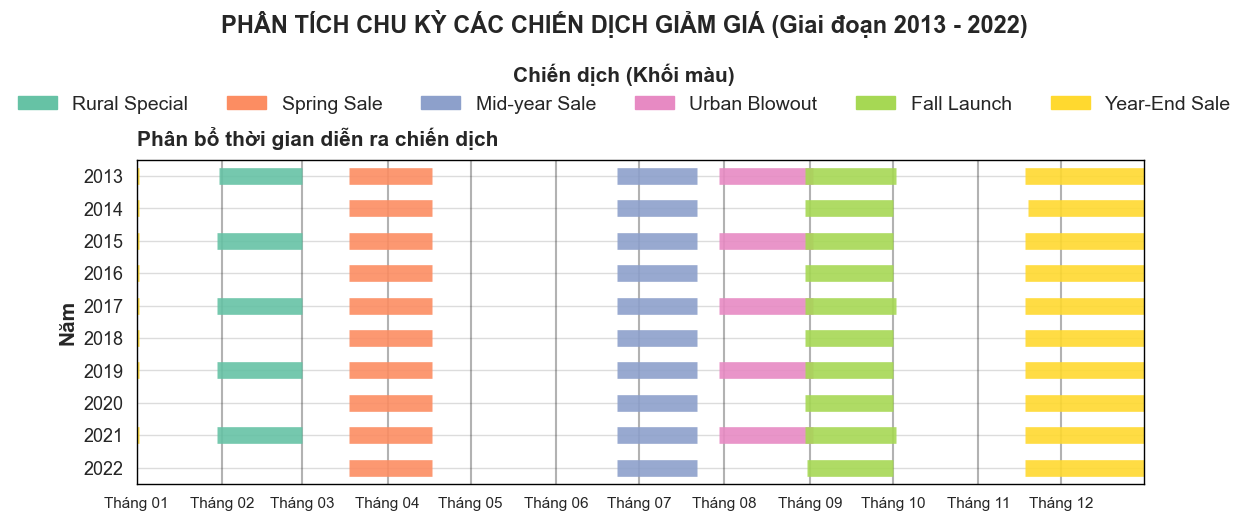

In [5284]:
# 1. XỬ LÝ DỮ LIỆU
df_plot = df_promotions.copy()
# Cắt bỏ năm và chuẩn hóa khoảng trắng
df_plot['base_promo'] = df_plot['promo_name'].str.replace(r'\s*\d{4}$', '', regex=True).str.strip()
# FIX KEYERROR: Ép kiểu chữ cho đúng với từ điển chuẩn
df_plot['base_promo'] = df_plot['base_promo'].replace({'Mid-Year Sale': 'Mid-year Sale'}) 

# Quy chiếu về năm 2020
df_plot['dummy_start'] = df_plot['start_date'].apply(lambda dt: dt.replace(year=dummy_year))
df_plot['dummy_end'] = df_plot['end_date'].apply(lambda dt: dt.replace(year=dummy_year))

# 2. VẼ BIỂU ĐỒ
fig, ax = plt.subplots(figsize=(13, 6))

for idx, row in df_plot.iterrows():
    start = row['dummy_start']
    end = row['dummy_end']
    color = camp_palette[row['base_promo']]
    
    if end < start: # Trường hợp vắt năm
        ax.hlines(y=row['year'], xmin=start, xmax=pd.to_datetime(f'{dummy_year}-12-31'), color=color, linewidth=12, alpha=0.9)
        ax.hlines(y=row['year'], xmin=pd.to_datetime(f'{dummy_year}-01-01'), xmax=end, color=color, linewidth=12, alpha=0.9)
    else:
        ax.hlines(y=row['year'], xmin=start, xmax=end, color=color, linewidth=12, alpha=0.9)

# 3. ĐỊNH DẠNG
min_year, max_year = int(df_plot['year'].min()), int(df_plot['year'].max())
ax.set_ylim(min_year - 0.5, max_year + 0.5)
ax.set_yticks(range(min_year, max_year + 1))
ax.invert_yaxis()

ax.set_xlim([pd.to_datetime(f'{dummy_year}-01-01'), pd.to_datetime(f'{dummy_year}-12-31')])
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('Tháng %m'))
ax.tick_params(axis='y', rotation=0, labelsize=13)
ax.tick_params(axis='x', rotation=0)

apply_standard_formatting(ax)

ax.set_ylabel('Năm', fontsize=15, fontweight='bold')
ax.set_xlabel('')
ax.set_title('Phân bổ thời gian diễn ra chiến dịch', loc='left', fontsize=15, fontweight='bold', pad=10)

# Legend & Title chính
legend_patches = [mpatches.Patch(color=color, label=promo) for promo, color in camp_palette.items()]
leg = fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, 0.84), ncol=len(camp_palette), frameon=False, fontsize=14)
leg.set_title('Chiến dịch (Khối màu)', prop={'weight':'bold', 'size':15})
leg._legend_box.align = "center"

fig.suptitle('PHÂN TÍCH CHU KỲ CÁC CHIẾN DỊCH GIẢM GIÁ (Giai đoạn 2013 - 2022)', fontsize=17, fontweight='bold', y=0.9)
plt.subplots_adjust(top=0.65)
plt.savefig('promotion.png', dpi=300, bbox_inches='tight')
plt.show()

#### INSIGHTS & BUSINESS IMPLICATIONS
- **Visual Context**: A diagnostic overlay comparing transaction lines against shaded campaign windows. Splitting into Even and Odd years acts as an A/B test to isolate the impact of specific odd-year campaigns.
- **Key Findings**:
    - **Absolute Dependency**: Almost 100% of revenue and volume spikes align perfectly with the shaded promotional periods. Sales are the sole engine of sudden cash flow.
    - **The Odd-Year Filler**: In Odd years, the introduction of "*Rural Special*" and "*Urban Blowout*" perfectly fills the revenue "valleys" observed in Even years (specifically in February and August).
- **Actionable Recommendations**:
    - **Beware of Promo-Addiction**: KThe business is heavily dependent on discounting to drive sales, which severely erodes Gross Margin. Customers are trained to wait for sales.
    - **Shift to Value-Added Promos**: Transition gradually from "Deep Discounting" to "Value-Added Promotions" (e.g., Buy 3 Get 1, free samples, triple loyalty points) for the `high_value_loyal` segment. This protects margins while maintaining high order volumes.

### 3.6. Correlating Revenue with Annual Campaigns (Even vs. Odd Years)
Since some major campaigns (Rural Special, Urban Blowout) only occur in odd years, we split the temporal analysis into Even and Odd years. We overlay the exact campaign windows (shaded regions) onto the transaction lines to measure the direct impact of marketing efforts on customer purchasing behavior.

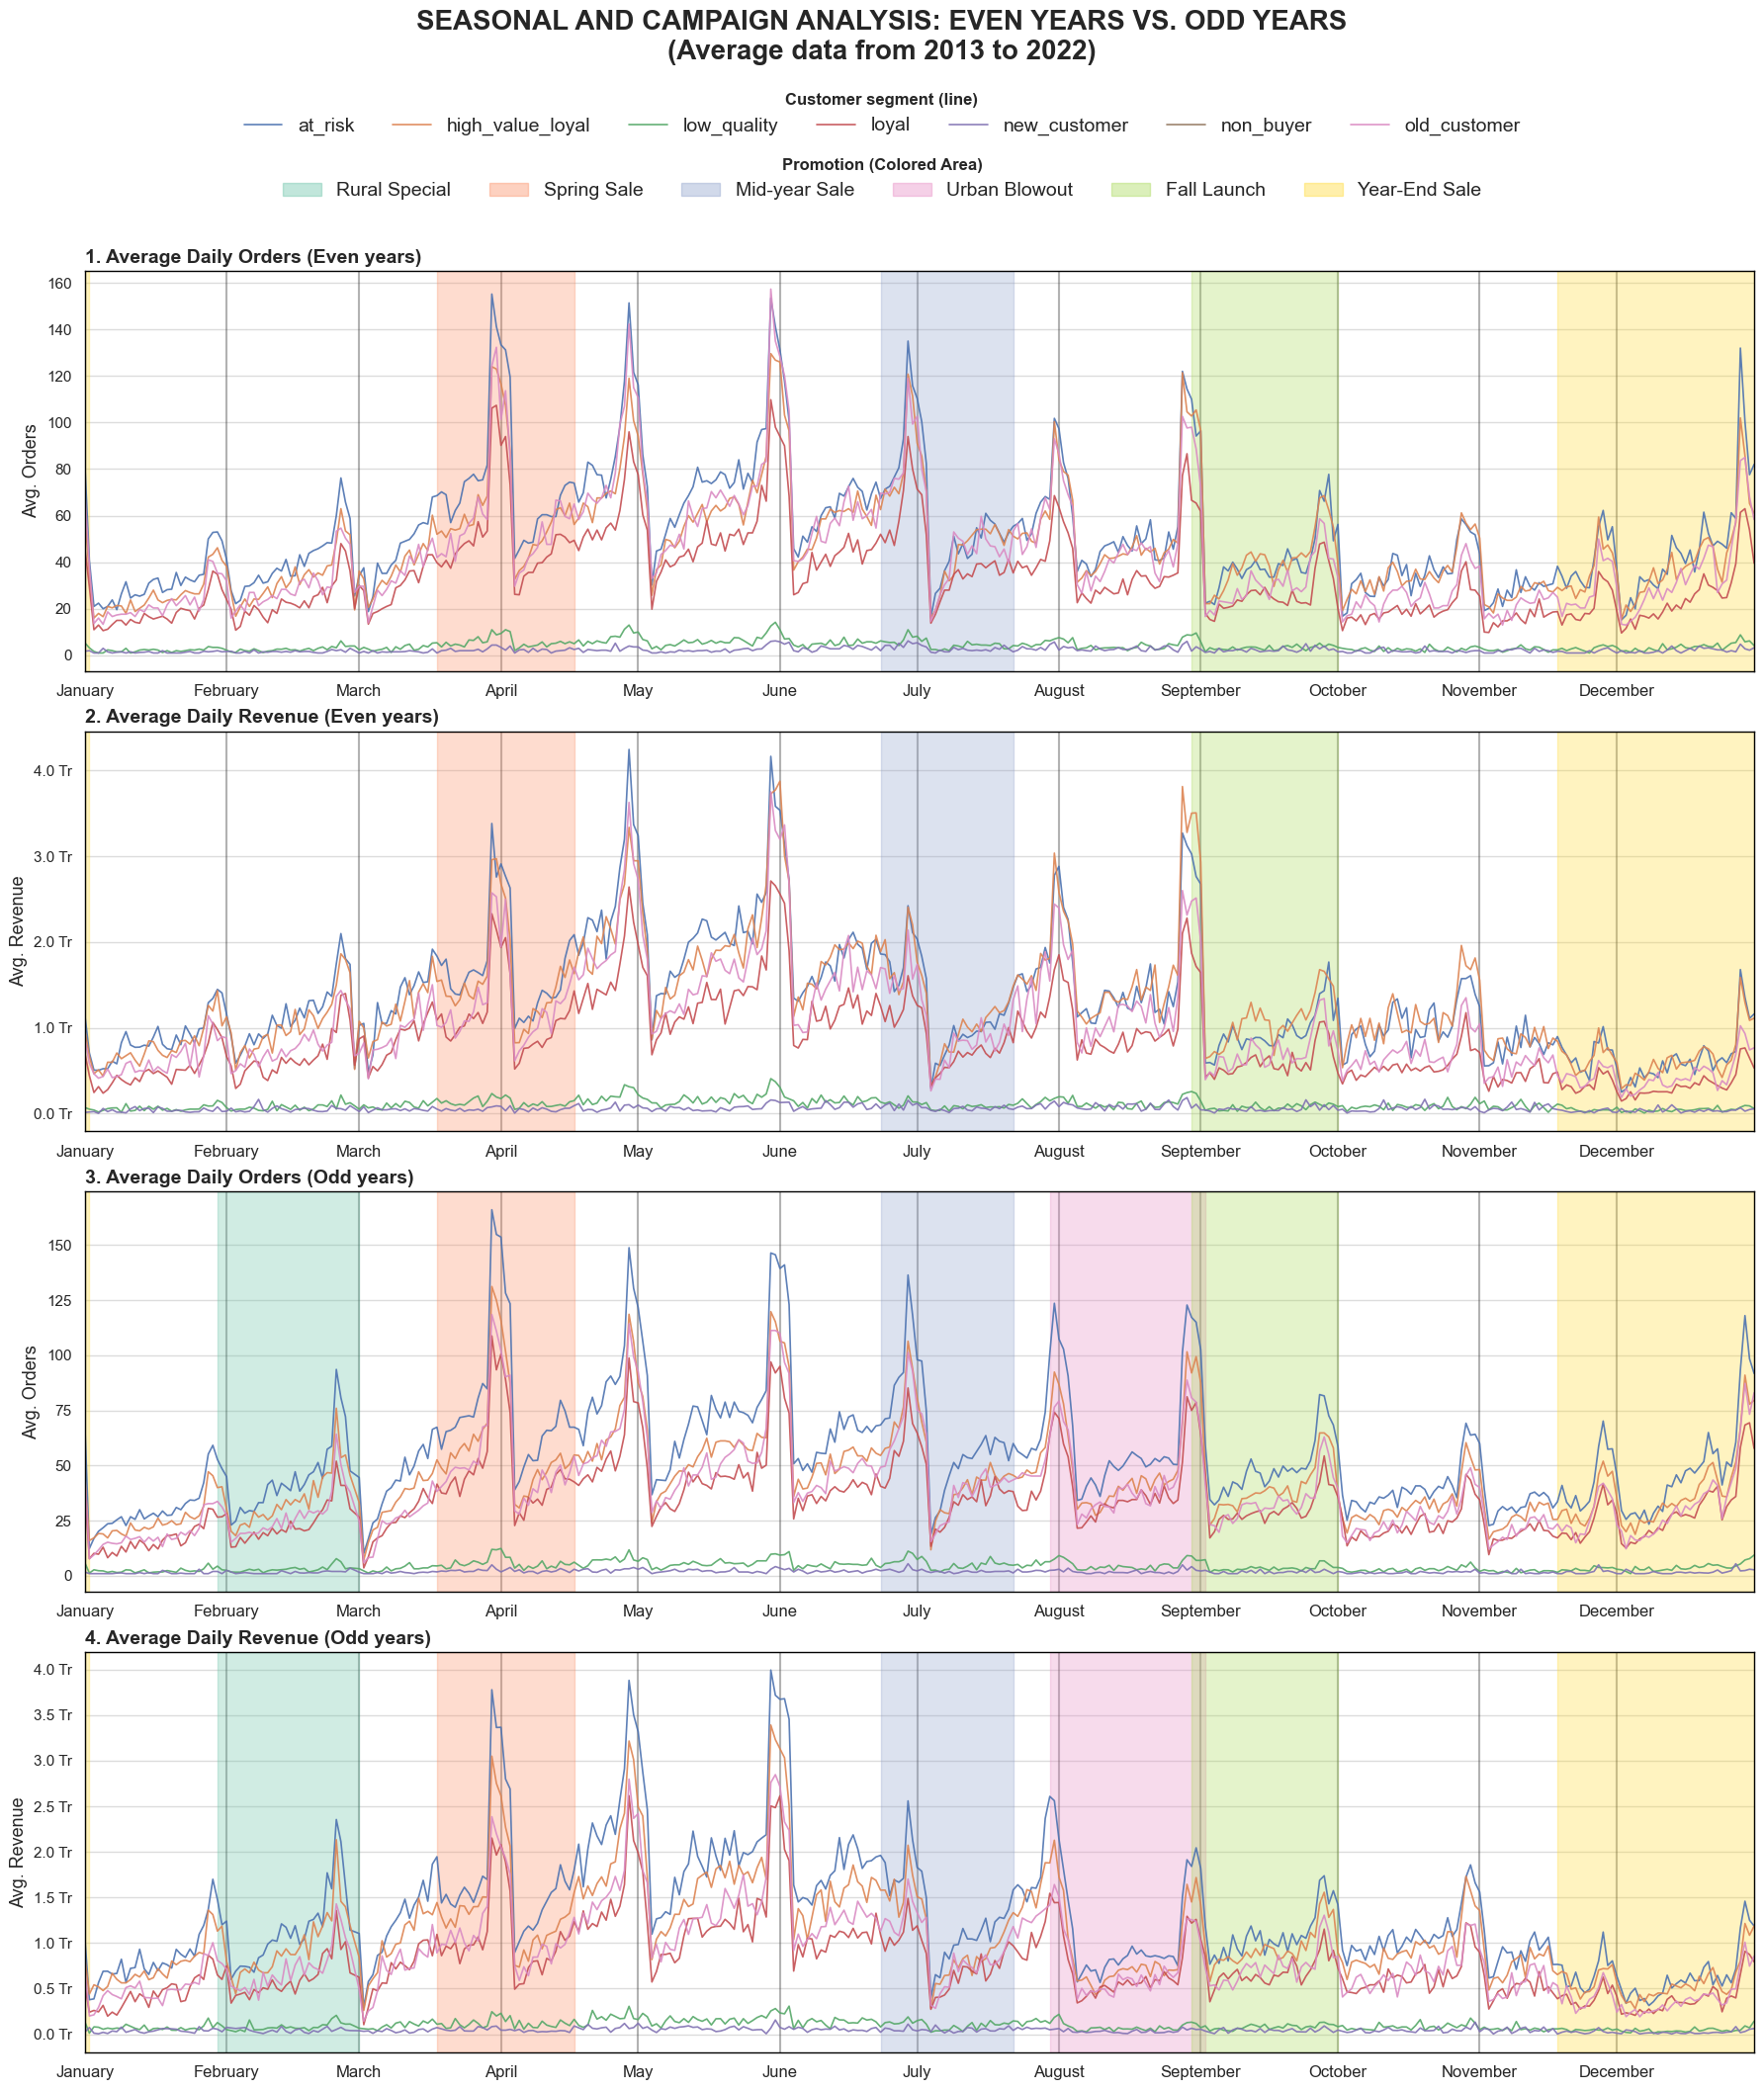

In [5285]:
# 1. XỬ LÝ DỮ LIỆU
filtered_df = daily_segment_df[
    (daily_segment_df['order_date'] >= start_date) & 
    (daily_segment_df['order_date'] <= end_date)
].copy()

filtered_df['month_day'] = filtered_df['order_date'].dt.strftime('%m-%d')
filtered_df['dummy_date'] = pd.to_datetime(str(dummy_year) + '-' + filtered_df['month_day'], errors='coerce')
filtered_df['is_even_year'] = filtered_df['order_date'].dt.year % 2 == 0

even_df = filtered_df[filtered_df['is_even_year']].groupby(['dummy_date', 'customer_segment'], observed=True)[['total_order', 'total_paid']].mean().reset_index()
odd_df = filtered_df[~filtered_df['is_even_year']].groupby(['dummy_date', 'customer_segment'], observed=True)[['total_order', 'total_paid']].mean().reset_index()

# 2. VẼ BIỂU ĐỒ
fig, axes = plt.subplots(4, 1, figsize=(18, 22), sharex=True)
fig.suptitle(f'SEASONAL AND CAMPAIGN ANALYSIS: EVEN YEARS VS. ODD YEARS\n(Average data from {start_date[:4]} to {end_date[:4]})', 
             fontsize=20, fontweight='bold', y=0.96)

plot_configs = [
    (even_df, 'total_order', '1. Average Daily Orders (Even years)', CAMPAIGNS_EVEN),
    (even_df, 'total_paid', '2. Average Daily Revenue (Even years)', CAMPAIGNS_EVEN),
    (odd_df, 'total_order', '3. Average Daily Orders (Odd years)', CAMPAIGNS_ODD),
    (odd_df, 'total_paid', '4. Average Daily Revenue (Odd years)', CAMPAIGNS_ODD)
]
ylabels = ['Avg. Orders', 'Avg. Revenue', 'Avg. Orders', 'Avg. Revenue']

for i, ax in enumerate(axes):
    data, y_col, title, camp_dict = plot_configs[i]
    
    sns.lineplot(data=data, x='dummy_date', y=y_col, hue='customer_segment', 
                 linewidth=1.2, alpha=0.9, ax=ax, legend=(i==0))
    
    # Dùng hàm helper để vẽ nền
    draw_campaign_spans(ax, camp_dict)
    
    ax.set_title(title, fontsize=14, fontweight='bold', loc='left')
    ax.set_ylabel(ylabels[i], fontsize=13)
    ax.set_xlabel('')
    apply_standard_formatting(ax)
    
    if i in [1, 3]:
        ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
        
    if i == 0:
        handles_seg, labels_seg = ax.get_legend_handles_labels()
        ax.get_legend().remove()

# 3. ĐỊNH DẠNG TRỤC X & LEGENDS
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
    ax.tick_params(axis='x', rotation=0, labelsize=12, labelbottom=True)
    ax.set_xlim([pd.to_datetime(f'{dummy_year}-01-01'), pd.to_datetime(f'{dummy_year}-12-31')])

# Legends
leg1 = fig.legend(handles=handles_seg, labels=labels_seg, loc='upper center', bbox_to_anchor=(0.5, 0.93), 
                  ncol=7, fontsize=14, frameon=False, title="Customer segment (line)")
leg1.get_title().set_fontweight('bold')

camp_handles = [mpatches.Patch(color=camp_palette[c], alpha=0.4, label=c) for c in ALL_CAMPAIGNS]
leg2 = fig.legend(handles=camp_handles, loc='upper center', bbox_to_anchor=(0.5, 0.90), 
                  ncol=6, fontsize=14, frameon=False, title="Promotion (Colored Area)")
leg2.get_title().set_fontweight('bold')

plt.tight_layout()
plt.subplots_adjust(top=0.84, hspace=0.15)
plt.show()

#### PHÂN TÍCH INSIGHTS: TƯƠNG QUAN KHUYẾN MÃI VÀ DOANH THU
- **Mô tả góc nhìn**: Biểu đồ đối chiếu trực diện (Diagnostic & Predictive) giữa vùng thời gian chạy chiến dịch (shaded areas) và biến động doanh thu thực tế. Phép thử phân tách "Năm Chẵn" và "Năm Lẻ" giúp cô lập và đo lường được tác động thực sự của các chiến dịch đặc thù.
- **Các phát hiện chính**:
    - **Sự cộng hưởng hoàn hảo**: Gần như 100% các đỉnh doanh thu và sản lượng đều rơi chính xác vào các vùng tô màu của chiến dịch khuyến mãi. Khuyến mãi chính là bộ đệm sinh ra dòng tiền đột biến.
    - **Kiểm định A/B tự nhiên**: Bức tranh của Năm Lẻ (có thêm Rural Special và Urban Blowout) cho thấy các chiến dịch này đã lấp đầy hoàn hảo những "vùng trũng" doanh thu từng xuất hiện ở Năm Chẵn (ví dụ giai đoạn tháng 2 và tháng 8).
- **Ý nghĩa kinh doanh & Đề xuất hành động**:
    - **Cảnh báo "Nghiện Khuyến Mãi"**: Doanh nghiệp đang bị phụ thuộc nặng nề vào các đợt sale để tạo ra doanh thu. Biên lợi nhuận gộp (Gross Margin) có thể bị ăn mòn nghiêm trọng.
    - **Hành động**: Cần chuyển dịch từ "Khuyến mãi giảm giá sâu" (Deep Discounting) sang "Khuyến mãi tạo giá trị" (Value-added Promotions) như: Mua 3 tặng 1, tặng kèm sản phẩm sample, hoặc nhân 3 điểm tích lũy thành viên cho nhóm high_value_loyal. Điều này vừa tạo ra đỉnh doanh thu, vừa bảo vệ được biên lợi nhuận của công ty.

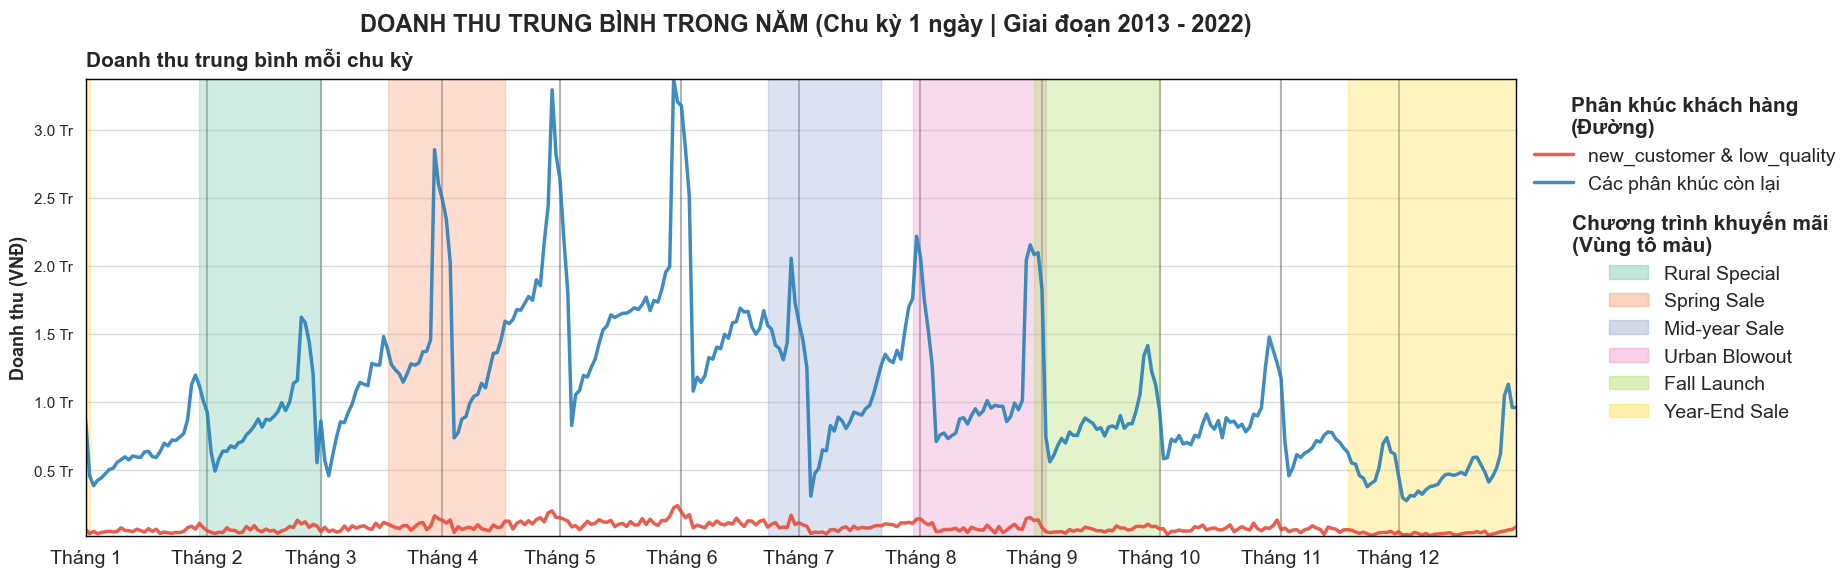

In [5286]:
# 1. XỬ LÝ DỮ LIỆU
df_all_years = daily_segment_df[
    (daily_segment_df['order_date'] >= start_date) & 
    (daily_segment_df['order_date'] <= end_date) & 
    (daily_segment_df['customer_segment'] != 'non_buyer')
].copy()

# Tối ưu logic gộp segment bằng numpy (nhanh và gọn hơn apply)
target_segments = ['new_customer', 'low_quality']
df_all_years['grouped_segment'] = np.where(df_all_years['customer_segment'].isin(target_segments), 
                                           'new_customer & low_quality', 'Các phân khúc còn lại')

df_all_years['month_day'] = df_all_years['order_date'].dt.strftime('%m-%d')
df_all_years['dummy_date'] = pd.to_datetime(str(dummy_year) + '-' + df_all_years['month_day'], errors='coerce')

avg_revenue_df = df_all_years.groupby(['dummy_date', 'grouped_segment'])['total_paid'].mean().reset_index()

# 2. VẼ BIỂU ĐỒ
fig, ax = plt.subplots(figsize=(22, 6))
fig.suptitle(f'DOANH THU TRUNG BÌNH TRONG NĂM (Chu kỳ 1 ngày | Giai đoạn {start_date[:4]} - {end_date[:4]})', 
             fontsize=17, fontweight='bold', y=0.96, x=0.37)

sns.lineplot(data=avg_revenue_df, x='dummy_date', y='total_paid', hue='grouped_segment',
             hue_order=['new_customer & low_quality', 'Các phân khúc còn lại'],
             palette=['#e74c3c', '#2980b9'], linewidth=2.5, alpha=0.9, ax=ax)

# Vẽ nền màu chiến dịch (Năm ODD chứa đầy đủ chiến dịch nhất)
draw_campaign_spans(ax, CAMPAIGNS_ODD)

# 3. ĐỊNH DẠNG & LEGENDS
ax.set_title('Doanh thu trung bình mỗi chu kỳ', fontsize=15, fontweight='bold', loc='left', pad=9)
ax.set_ylabel('Doanh thu (VNĐ)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.margins(y=0)

apply_standard_formatting(ax)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(vietnamese_months))
ax.tick_params(axis='x', rotation=0, labelsize=14)
ax.set_xlim([pd.to_datetime(f'{dummy_year}-01-01'), pd.to_datetime(f'{dummy_year}-12-31')])
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

# Tạo Global Legends
handles_seg, labels_seg = ax.get_legend_handles_labels()
ax.get_legend().remove()

# 1. Legend Phân khúc khách hàng (Nằm bên phải, góc trên)
# Tọa độ x=1.02 (nhích ra ngoài rìa phải), y=1 (ngang bằng mép trên của trục)
leg1 = ax.legend(handles=handles_seg, labels=labels_seg, 
                 loc='upper left', bbox_to_anchor=(1, 1),
                 ncol=1, fontsize=14, frameon=False, 
                 title="Phân khúc khách hàng\n(Đường)",
                 title_fontsize=15)
leg1.get_title().set_fontweight('bold')

# Bắt buộc phải có hàm add_artist này để giữ leg1 không bị leg2 đè mất
ax.add_artist(leg1)

# 2. Legend Chương trình khuyến mãi (Nằm bên phải, ngay dưới leg1)
camp_handles = [mpatches.Patch(color=camp_palette[c], alpha=0.4, label=campaign_vn.get(c, c)) for c in CAMPAIGNS_ODD.keys()]

# Tọa độ y hạ xuống tầm 0.7 để nhường chỗ cho khối legend trên
leg2 = ax.legend(handles=camp_handles, 
                 loc='upper left', bbox_to_anchor=(1.027, 0.75),
                 ncol=1, fontsize=14, frameon=False, 
                 title="Chương trình khuyến mãi\n(Vùng tô màu)",
                 title_fontsize=15)
leg2.get_title().set_fontweight('bold')

# 3. Căn chỉnh lại khoảng cách khung hình
# plt.subplots_adjust(top=0.84, right=0.5)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('daily_avg.png', dpi=300, bbox_inches='tight')
plt.show()